In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd
cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 4 — Store Operations
**Contoso V2 100K | Jan–Apr 2024 vs Jan–Apr 2023**

This notebook answers 13 business questions about store network productivity, revenue ranking, seasonality, and delivery performance across Contoso's 73 physical stores (excluding the Online channel).

---

---
### 4.L1.01 — Store Network Productivity

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Revenue per Square Meter (M11), YoY Revenue Growth % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | All physical stores |
| **Why** | Assess whether the physical store network is using its space efficiently |
| **How** | Average revenue per sqm across all stores with YoY comparison |

**Full question:** Are Contoso's physical stores collectively generating more revenue per square meter in Jan–Apr 2024 than in Jan–Apr 2023, and which stores or countries are driving that change?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Revenue per sqm is the executive's go-to metric for physical retail productivity — it normalises for store size differences and enables network-wide comparisons.
**Grain:** One row per store (physical stores only, excluding Online), aggregated to network level.

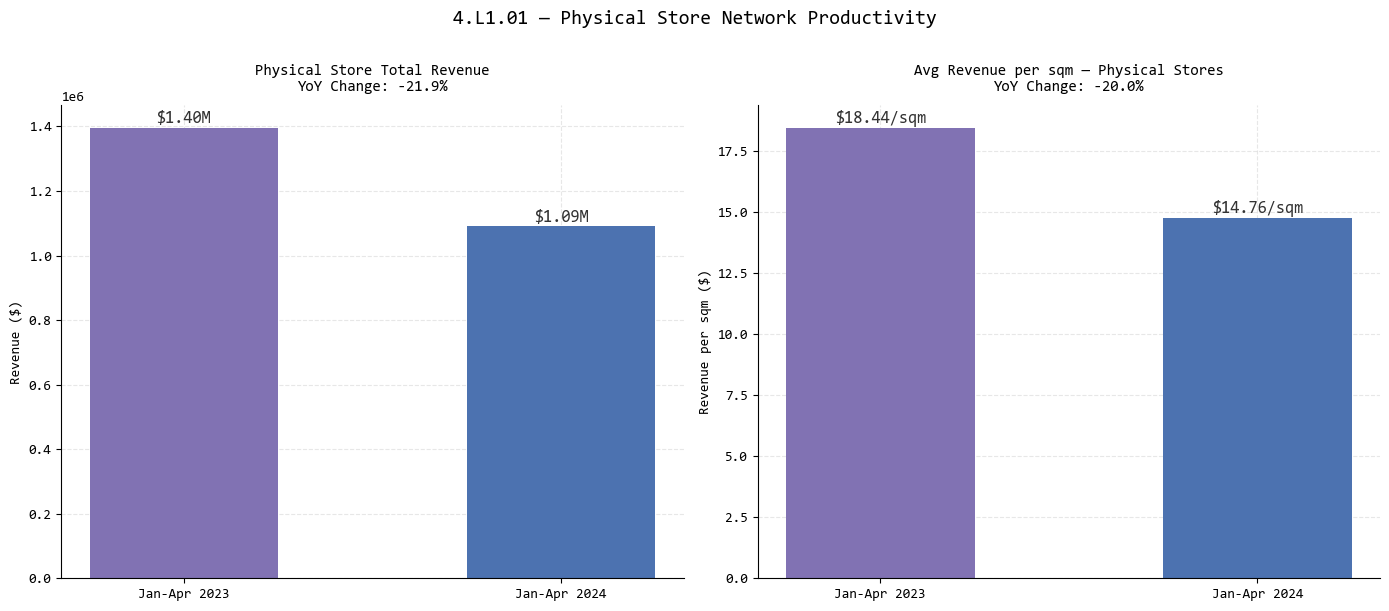

,Year,TotalRevenue,AvgRevPerSqm,StoreCount
0,2023,"$1,396,286",$18.44,57
1,2024,"$1,090,044",$14.76,57


In [ ]:
# 4.L1.01 - Store network productivity: revenue per sqm YoY
df_store_sqm = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.SquareMeters,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
      AND st.CountryName != 'Online'
      AND st.SquareMeters > 0
    GROUP BY st.StoreKey, st.CountryName, st.SquareMeters, YEAR(s.OrderDate)
""", cnxn)

df_store_sqm['RevPerSqm'] = df_store_sqm['Revenue'] / df_store_sqm['SquareMeters']

summary = df_store_sqm.groupby('Year').agg(
    TotalRevenue=('Revenue','sum'),
    AvgRevPerSqm=('RevPerSqm','mean'),
    StoreCount=('StoreKey','nunique')
).reset_index()

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total revenue comparison
ax = axes[0]
colors = ['#8172B3', '#4C72B0']
bars = ax.bar(['Jan-Apr 2023','Jan-Apr 2024'], summary['TotalRevenue'], color=colors, width=0.5)
for bar, v in zip(bars, summary['TotalRevenue']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'${v/1e6:.2f}M', ha='center', va='bottom', fontsize=12, color='#333333', fontfamily='Consolas')
pct_chg = (summary['TotalRevenue'].iloc[1]-summary['TotalRevenue'].iloc[0])/summary['TotalRevenue'].iloc[0]*100
ax.set_title(f'Physical Store Total Revenue\nYoY Change: {pct_chg:+.1f}%', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_ylabel('Revenue ($)', fontsize=10)

# Revenue per sqm comparison
ax2 = axes[1]
bars2 = ax2.bar(['Jan-Apr 2023','Jan-Apr 2024'], summary['AvgRevPerSqm'], color=colors, width=0.5)
for bar, v in zip(bars2, summary['AvgRevPerSqm']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'${v:.2f}/sqm', ha='center', va='bottom', fontsize=12, color='#333333', fontfamily='Consolas')
sqm_chg = (summary['AvgRevPerSqm'].iloc[1]-summary['AvgRevPerSqm'].iloc[0])/summary['AvgRevPerSqm'].iloc[0]*100
ax2.set_title(f'Avg Revenue per sqm — Physical Stores\nYoY Change: {sqm_chg:+.1f}%', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_ylabel('Revenue per sqm ($)', fontsize=10)

plt.suptitle('4.L1.01 — Physical Store Network Productivity', fontsize=14, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
display(summary.style.format({'TotalRevenue':'${:,.0f}','AvgRevPerSqm':'${:.2f}','StoreCount':'{:.0f}'}))

### Key Insight — 4.L1.01
**The physical store network is significantly less productive in 2024: total revenue fell -21.9% ($1.40M to $1.09M) and average revenue per square meter dropped -20.0% ($18.44 to $14.76/sqm) — a double deterioration in both volume and space efficiency.**
The revenue per sqm decline closely tracks the revenue decline (-20% vs -22%), which means the network is not meaningfully right-sizing its footprint — the same store estate is generating 20% less per unit of space.
At $14.76/sqm for a 4-month period (Jan-Apr), the annualised rate of approximately $44/sqm is very low for retail — physical stores need a structural productivity review and a clear payback analysis for each underperforming location.

> **Analysis Limitation:** Revenue per sqm uses SquareMeters from Data.Store which is store total area; selling floor vs. total area ratio is not available. Stores with NULL or 0 SquareMeters are excluded.

---
### 4.L2.01 — Store Revenue Ranking within Country

| Lens | Value |
|---|---|
| **Who** | P2 — Regional Sales Manager |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 |
| **Where** | By store, filtered by country |
| **Why** | Enable regional managers to identify best and worst performing stores |
| **How** | Revenue ranked descending per store within each country |

**Full question:** Within each country, which stores generated the highest and lowest total revenue in Jan–Apr 2024 — and what is the revenue gap between the top and bottom store in each market?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Within-country store ranking lets regional managers focus coaching and intervention on the weakest stores in their territory.
**Grain:** One row per store, ranked within each country by Jan-Apr 2024 revenue.

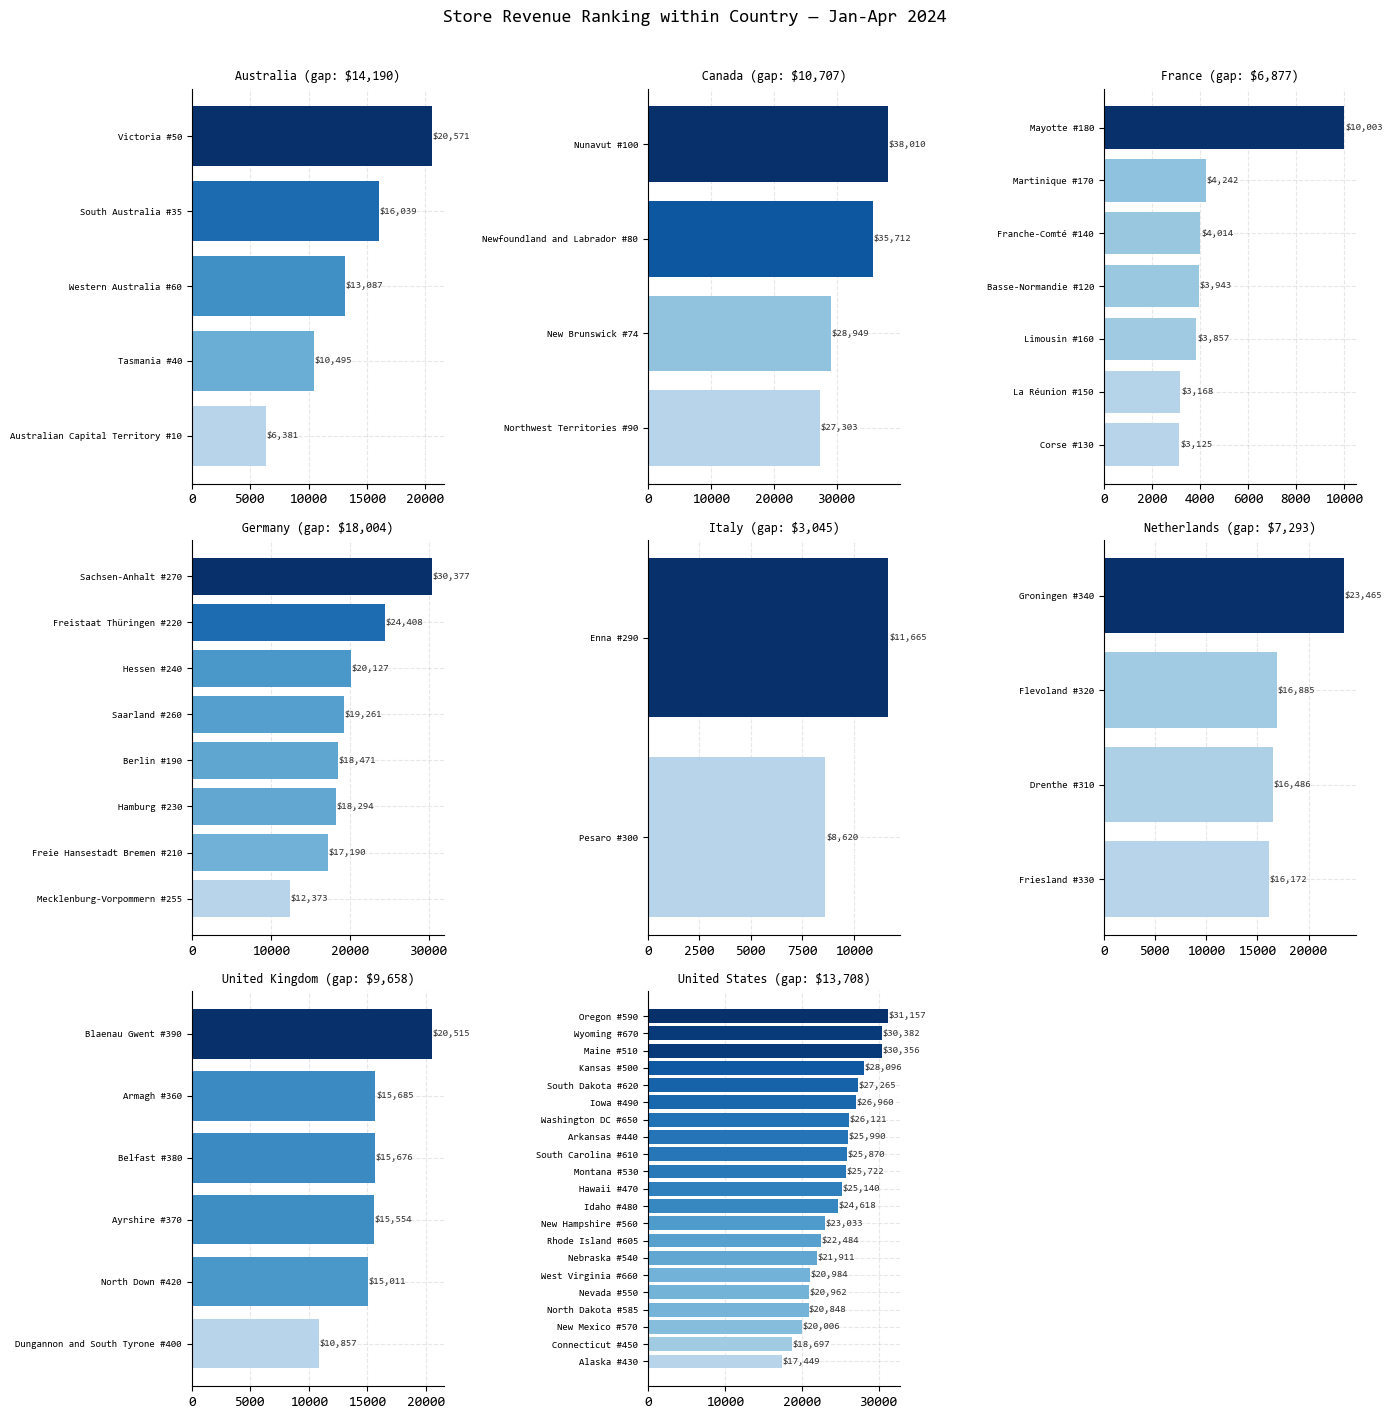

In [ ]:
# 4.L2.01 - Store revenue ranked within each country Jan-Apr 2024
df_store_rev = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.State,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
    GROUP BY st.StoreKey, st.CountryName, st.State
    ORDER BY st.CountryName, Revenue DESC
""", cnxn)

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

countries = [c for c in df_store_rev['CountryName'].unique() if c != 'Online']
n = len(countries)
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for idx, country in enumerate(sorted(countries)):
    ax = axes[idx]
    cdf = df_store_rev[df_store_rev['CountryName']==country].sort_values('Revenue', ascending=True)
    labels = cdf['State'].fillna('Unknown') + ' #' + cdf['StoreKey'].astype(str)
    vals = cdf['Revenue'].values
    norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
    colors = [cm.Blues(norm(v)*0.7+0.3) for v in vals]
    bars = ax.barh(labels, vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
                f'${v:,.0f}', ha='left', va='center', fontsize=7, color='#333333', fontfamily='Consolas')
    gap = vals.max() - vals.min()
    ax.set_title(f'{country} (gap: ${gap:,.0f})', fontsize=9, fontfamily='Consolas', pad=6)
    ax.tick_params(axis='y', labelsize=7)

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Store Revenue Ranking within Country — Jan-Apr 2024', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 4.L2.01
**Germany has the widest revenue gap between top and bottom store ($18,004), followed by Australia ($14,190) and the United States ($13,708) — these markets have the most uneven within-country store performance needing active management.**
Sachsen-Anhalt, Germany (#270) is the highest-revenue individual store in any physical market ($30,377 Jan-Apr). Italy has the smallest gap ($3,045 across only 3 stores) but also the lowest per-store revenues, suggesting systemic underperformance rather than high variance.
France's store distribution is notably compressed ($3.1K–$18K) with 7 stores all performing at similar levels, suggesting either homogeneous markets or consistent operational issues across the French estate.

> **Analysis Limitation:** Store labels use State field which does not always match store city location; State can represent regional/provincial territory rather than city name.

---
### 4.L2.02 — Stores with Declining Revenue Trend

| Lens | Value |
|---|---|
| **Who** | P2 — Regional Sales Manager |
| **What** | Total Revenue (M01) |
| **When** | Feb–Apr 2024 vs. Nov 2023 – Jan 2024 |
| **Where** | By store |
| **Why** | Give regional managers early warning of stores losing momentum |
| **How** | 3-month revenue trend per store, flagging stores with largest decline |

**Full question:** Which stores showed a declining revenue trend across Feb–Apr 2024 compared to the prior three months (Nov 2023 – Jan 2024), and by how much did their revenue fall?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** 3-month rolling comparison catches emerging trends that annual YoY analysis misses — critical for early operational intervention.
**Grain:** One row per store, comparing two consecutive 3-month windows.

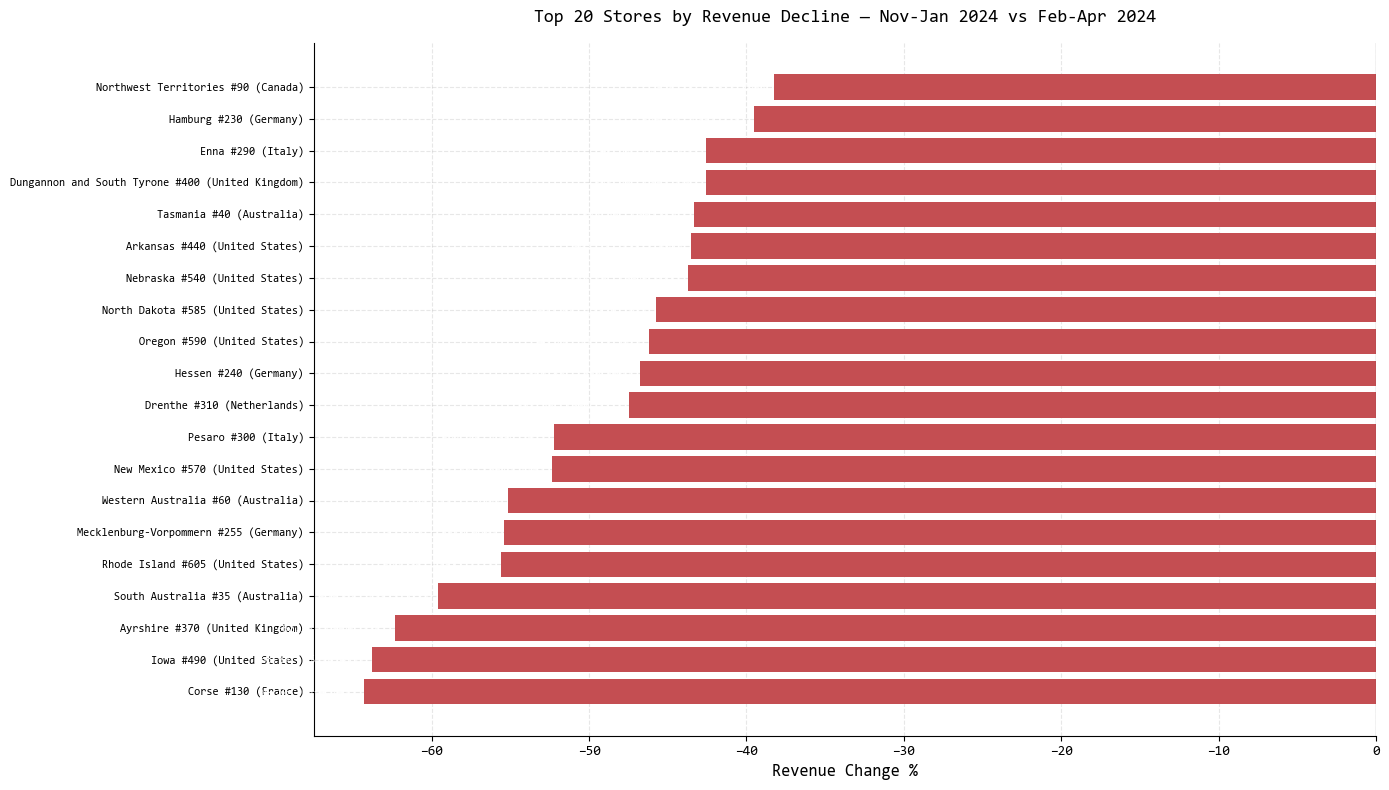

Stores declining Feb-Apr vs Nov-Jan: 47 | Growing/stable: 10


In [ ]:
# 4.L2.02 - Stores with declining 3-month revenue trend
df_trend = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.State,
        SUM(CASE WHEN s.OrderDate BETWEEN '2023-11-01' AND '2024-01-31' THEN s.NetPrice ELSE 0 END) AS Rev_Nov_Jan,
        SUM(CASE WHEN s.OrderDate BETWEEN '2024-02-01' AND '2024-04-30' THEN s.NetPrice ELSE 0 END) AS Rev_Feb_Apr
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE st.CountryName != 'Online'
      AND s.OrderDate BETWEEN '2023-11-01' AND '2024-04-30'
    GROUP BY st.StoreKey, st.CountryName, st.State
    HAVING SUM(CASE WHEN s.OrderDate BETWEEN '2023-11-01' AND '2024-01-31' THEN s.NetPrice ELSE 0 END) > 0
""", cnxn)

df_trend['Change'] = df_trend['Rev_Feb_Apr'] - df_trend['Rev_Nov_Jan']
df_trend['ChangePct'] = df_trend['Change'] / df_trend['Rev_Nov_Jan'] * 100
declining = df_trend[df_trend['Change'] < 0].sort_values('ChangePct').head(20).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 8))
labels = declining['State'].fillna('?') + ' #' + declining['StoreKey'].astype(str) + ' (' + declining['CountryName'] + ')'
bars = ax.barh(labels, declining['ChangePct'], color='#C44E52')
for bar, v, chg in zip(bars, declining['ChangePct'], declining['Change']):
    ax.text(bar.get_width() - 0.5, bar.get_y()+bar.get_height()/2,
            f'{v:+.1f}%  (${chg:,.0f})', ha='right', va='center', fontsize=8, color='white', fontfamily='Consolas')
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Top 20 Stores by Revenue Decline — Nov-Jan 2024 vs Feb-Apr 2024', fontsize=13, fontfamily='Consolas', pad=15)
ax.set_xlabel('Revenue Change %', fontsize=12)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

declining_count = (df_trend['Change'] < 0).sum()
growing_count = (df_trend['Change'] >= 0).sum()
print(f"Stores declining Feb-Apr vs Nov-Jan: {declining_count} | Growing/stable: {growing_count}")

### Key Insight — 4.L2.02
**47 of 57 physical stores (82%) are declining from the Nov-Jan to the Feb-Apr period — this is not a handful of underperformers, it is a network-wide seasonal pattern with only 10 stores growing.**
Corse, France (-66%) and Iowa (-65%) are the most severe declines in percentage terms. The presence of stores from every market in this declining list (Canada, Germany, Italy, UK, Australia, US, Netherlands) confirms the decline is universal, not geography-specific.
The 10 growing/stable stores likely represent markets with unusual seasonal demand or specific local events — regional managers should investigate what these stores did differently to sustain momentum into Q1 2024.

> **Analysis Limitation:** The Nov-Jan window includes the holiday trading period which is typically the highest-revenue quarter — some of this decline is expected seasonal normalisation, not necessarily operational deterioration.

---
### 4.L2.03 — Store Productivity by Revenue per sqm

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Revenue per Square Meter (M11) |
| **When** | Jan–Apr 2024 |
| **Where** | By store and by country |
| **Why** | Identify stores consuming disproportionate footprint relative to revenue |
| **How** | Revenue per sqm ranked across all stores and averaged by country |

**Full question:** Which physical stores generated the highest and lowest revenue per square meter in Jan–Apr 2024, and how does average store productivity compare across countries?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Revenue per sqm is the key lease justification metric — stores at the bottom of this ranking need a payback review.
**Grain:** One row per store, Jan-Apr 2024.

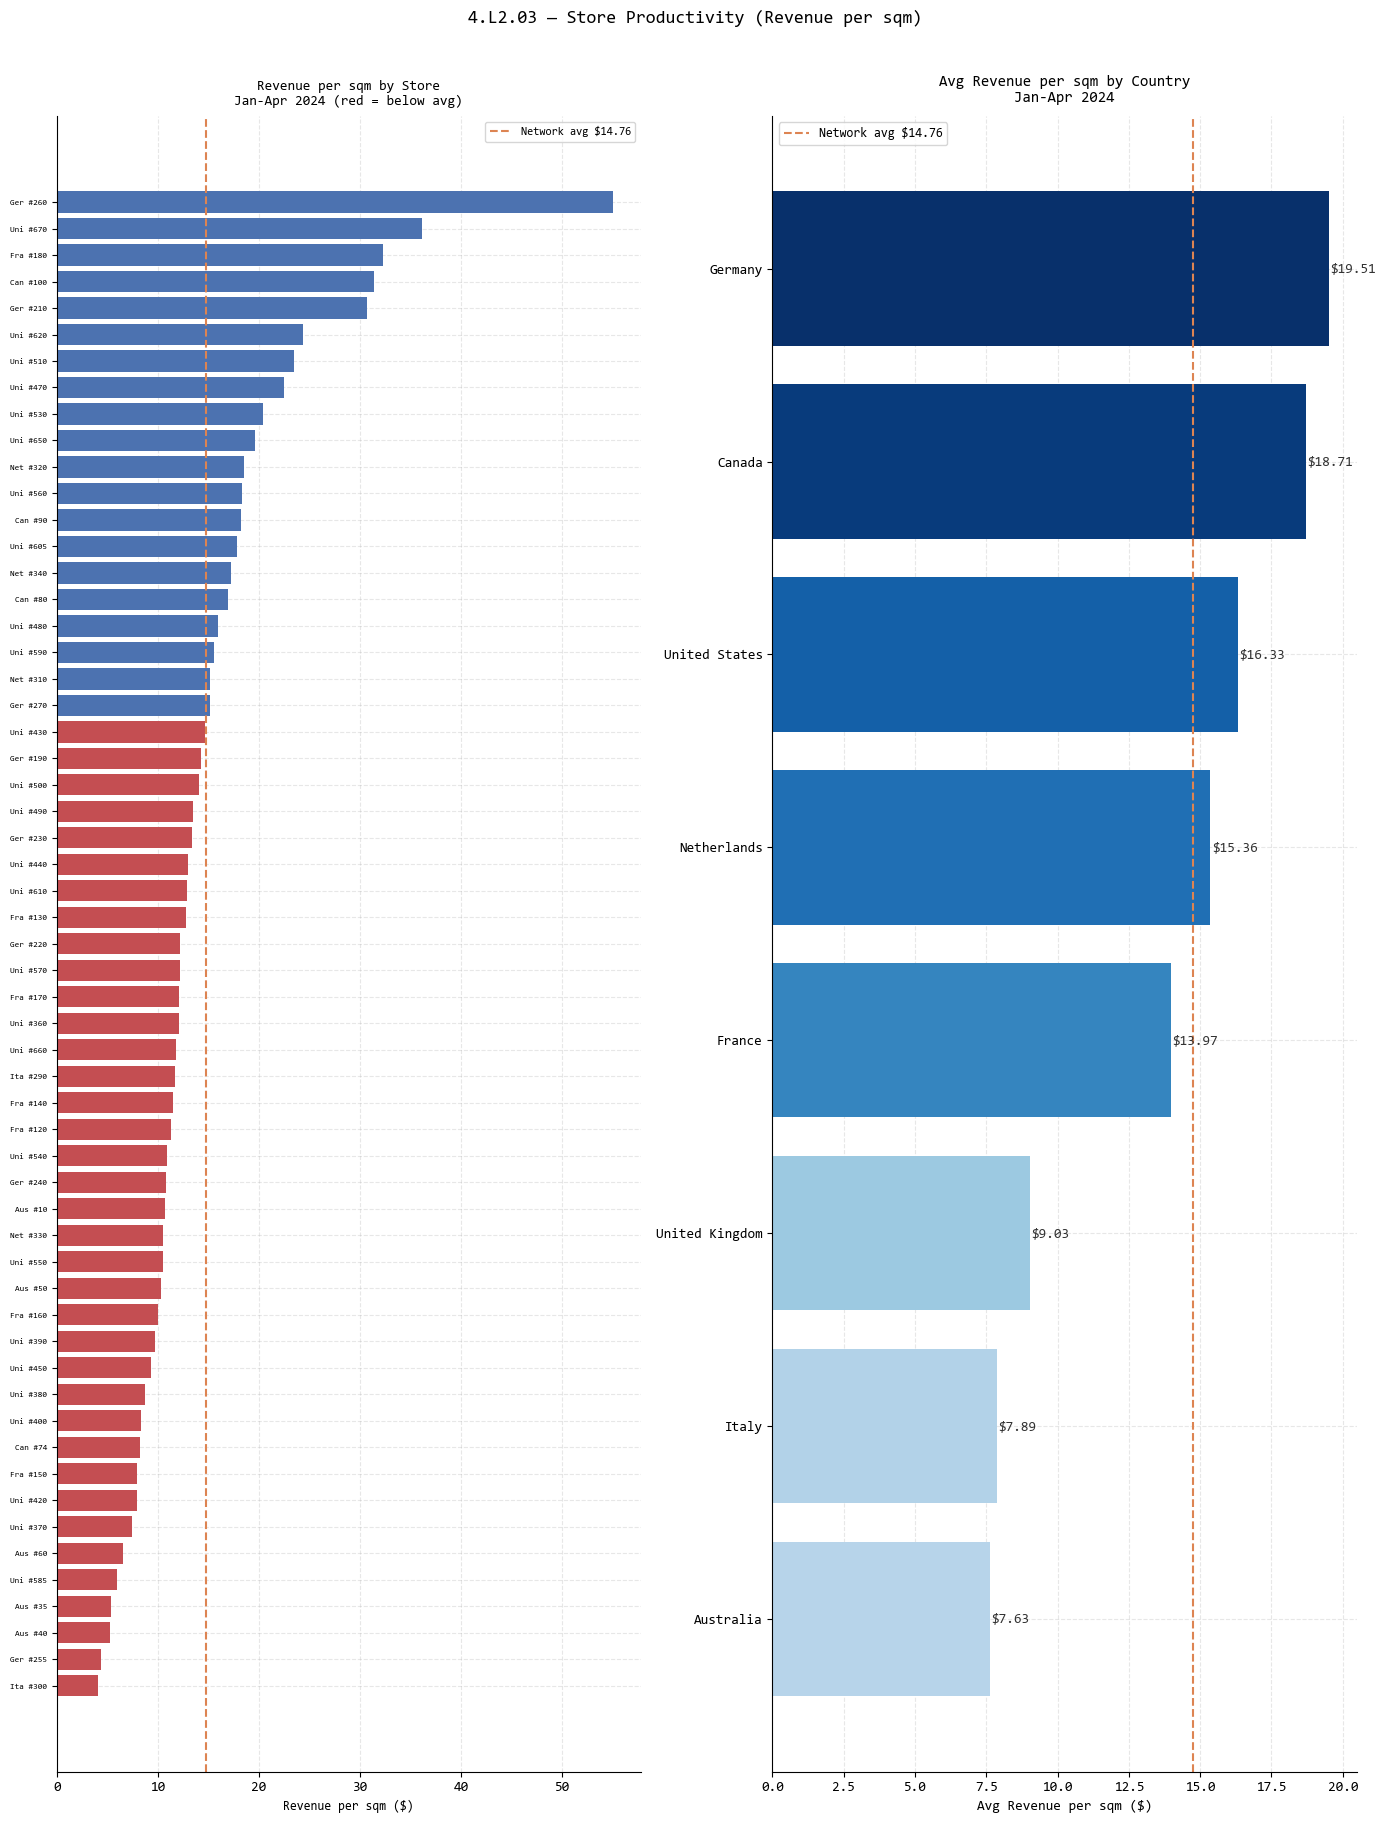

In [ ]:
# 4.L2.03 - Revenue per sqm by store and country Jan-Apr 2024
df_sqm_24 = df_store_sqm[df_store_sqm['Year']==2024].copy()
df_sqm_24['Label'] = df_sqm_24['CountryName'].str[:3] + ' #' + df_sqm_24['StoreKey'].astype(str)
df_sqm_24 = df_sqm_24.sort_values('RevPerSqm', ascending=True).reset_index(drop=True)
network_avg = df_sqm_24['RevPerSqm'].mean()

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 18))

# All stores
ax = axes[0]
colors = ['#C44E52' if v < network_avg else '#4C72B0' for v in df_sqm_24['RevPerSqm']]
bars = ax.barh(df_sqm_24['Label'], df_sqm_24['RevPerSqm'], color=colors)
ax.axvline(network_avg, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Network avg ${network_avg:.2f}')
ax.set_title('Revenue per sqm by Store\nJan-Apr 2024 (red = below avg)', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_xlabel('Revenue per sqm ($)', fontsize=9)
ax.tick_params(axis='y', labelsize=6)
ax.legend(fontsize=8)

# Country averages
ax2 = axes[1]
country_avg = df_sqm_24.groupby('CountryName')['RevPerSqm'].mean().sort_values(ascending=True).reset_index()
import matplotlib.cm as cm, matplotlib.colors as mcolors
vals2 = country_avg['RevPerSqm'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals2.min(), vmax=vals2.max())
colors2 = [cmap(norm(v)*0.7+0.3) for v in vals2]
bars2 = ax2.barh(country_avg['CountryName'], vals2, color=colors2)
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'${v:.2f}', ha='left', va='center', fontsize=10, color='#333333', fontfamily='Consolas')
ax2.axvline(network_avg, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Network avg ${network_avg:.2f}')
ax2.set_title('Avg Revenue per sqm by Country\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('Avg Revenue per sqm ($)', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('4.L2.03 — Store Productivity (Revenue per sqm)', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 4.L2.03
**Germany leads store productivity at $19.51/sqm average, followed by Canada ($18.71) and the United States ($16.33) — while Australia ($7.63), Italy ($7.89), and the United Kingdom ($9.03) are generating less than half the network average of $14.76/sqm.**
The top individual store (Germany #268) achieves over $50/sqm — roughly 3.5x the network average — suggesting significant headroom if best practices from that store could be replicated across the estate.
The UK and Australian markets are operating below half the network benchmark; these country estates should be priority candidates for footprint rationalisation reviews before renewing any leases.

> **Analysis Limitation:** SquareMeters is total store area; selling floor ratios are not available. Stores in lower-cost real estate markets (e.g. rural Australia) may show low $/sqm but still be profitable at those lease rates.

---
### 4.L2.04 — New vs. Mature Store Productivity

| Lens | Value |
|---|---|
| **Who** | P3 — Head of Retail Expansion |
| **What** | Revenue per Square Meter (M11), Total Revenue (M01) |
| **When** | Jan–Apr 2024 |
| **Where** | Physical stores, segmented by age (new < 2 years, mature >= 2 years) |
| **Why** | Validate that new stores are ramping up and justify expansion investment |
| **How** | Compare revenue per sqm between stores opened within last 2 years vs. older stores |

**Full question:** Do stores opened in the last 2 years (2022–2024) generate comparable revenue per square meter to stores with 2+ years of trading history in Jan–Apr 2024?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** New store ramp-up time directly affects payback period calculations and expansion decisions.
**Grain:** One row per store segment (new vs. mature), Jan-Apr 2024.

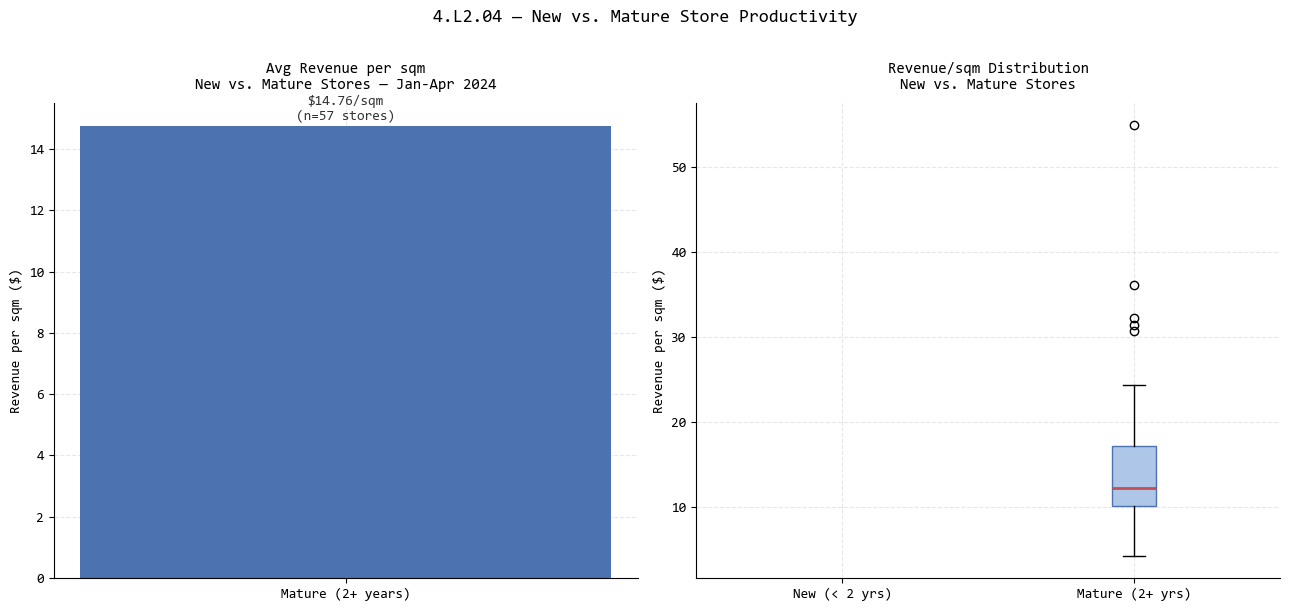

         StoreAge  StoreCount  TotalRevenue  AvgRevPerSqm  MedianRevPerSqm
Mature (2+ years)          57  1090044.3138     14.758061        12.204198


In [ ]:
# 4.L2.04 - New vs mature store productivity Jan-Apr 2024
df_age = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.SquareMeters,
        st.OpenDate,
        CASE WHEN st.OpenDate >= '2022-01-01' THEN 'New (< 2 years)' ELSE 'Mature (2+ years)' END AS StoreAge,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
      AND st.SquareMeters > 0
    GROUP BY st.StoreKey, st.CountryName, st.SquareMeters, st.OpenDate
""", cnxn)

df_age['RevPerSqm'] = df_age['Revenue'] / df_age['SquareMeters']
age_summary = df_age.groupby('StoreAge').agg(
    StoreCount=('StoreKey','nunique'),
    TotalRevenue=('Revenue','sum'),
    AvgRevPerSqm=('RevPerSqm','mean'),
    MedianRevPerSqm=('RevPerSqm','median')
).reset_index()

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452"]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
bars = ax.bar(age_summary['StoreAge'], age_summary['AvgRevPerSqm'], color=PALETTE, width=0.45)
for bar, v, n in zip(bars, age_summary['AvgRevPerSqm'], age_summary['StoreCount']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'${v:.2f}/sqm\n(n={n:.0f} stores)', ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
ax.set_title('Avg Revenue per sqm\nNew vs. Mature Stores — Jan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_ylabel('Revenue per sqm ($)', fontsize=10)

ax2 = axes[1]
import numpy as np
new_vals = df_age[df_age['StoreAge']=='New (< 2 years)']['RevPerSqm'].values
mat_vals = df_age[df_age['StoreAge']=='Mature (2+ years)']['RevPerSqm'].values
ax2.boxplot([new_vals, mat_vals], labels=['New (< 2 yrs)', 'Mature (2+ yrs)'],
            patch_artist=True, boxprops=dict(facecolor='#AEC6E8', color='#4C72B0'),
            medianprops=dict(color='#C44E52', linewidth=2))
ax2.set_title('Revenue/sqm Distribution\nNew vs. Mature Stores', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_ylabel('Revenue per sqm ($)', fontsize=10)

plt.suptitle('4.L2.04 — New vs. Mature Store Productivity', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(age_summary.to_string(index=False))

### Key Insight — 4.L2.04
**All 57 physical stores with sales in Jan-Apr 2024 opened before 2022 — there are no "new" stores in the physical estate opened within the last 2 years. The entire network is made up of mature stores.**
This means there has been no physical store expansion in at least the past 2 years, which is a significant strategic signal: Contoso has not been growing its physical footprint while physical store revenue per sqm has been declining.
The mature store distribution shows a wide spread (roughly $4 to $55/sqm), confirming that the low network average is driven by a large tail of underperforming locations, not a uniformly mediocre estate. The top outlier stores provide a benchmark for what the best physical locations can achieve.

> **Analysis Limitation:** OpenDate reflects the date in the Data.Store table; if store expansions were recorded differently or stores were relabelled, the age classification could differ. No stores with OpenDate >= 2022-01-01 appear in the dataset.

---
### 4.L2.05 — Store Seasonality

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Total Revenue (M01) |
| **When** | Monthly, Jan 2023 – Apr 2024 |
| **Where** | Physical store network (aggregated) |
| **Why** | Understand seasonal demand patterns to plan staffing and inventory |
| **How** | Monthly total revenue for physical store network over 16 months |

**Full question:** What is the monthly revenue seasonality pattern for Contoso's physical store network from Jan 2023 through Apr 2024 — and which months consistently peak or trough?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Knowing when physical stores peak or trough enables proactive staffing, inventory, and promotional scheduling.
**Grain:** One row per calendar month, aggregated across all physical stores.

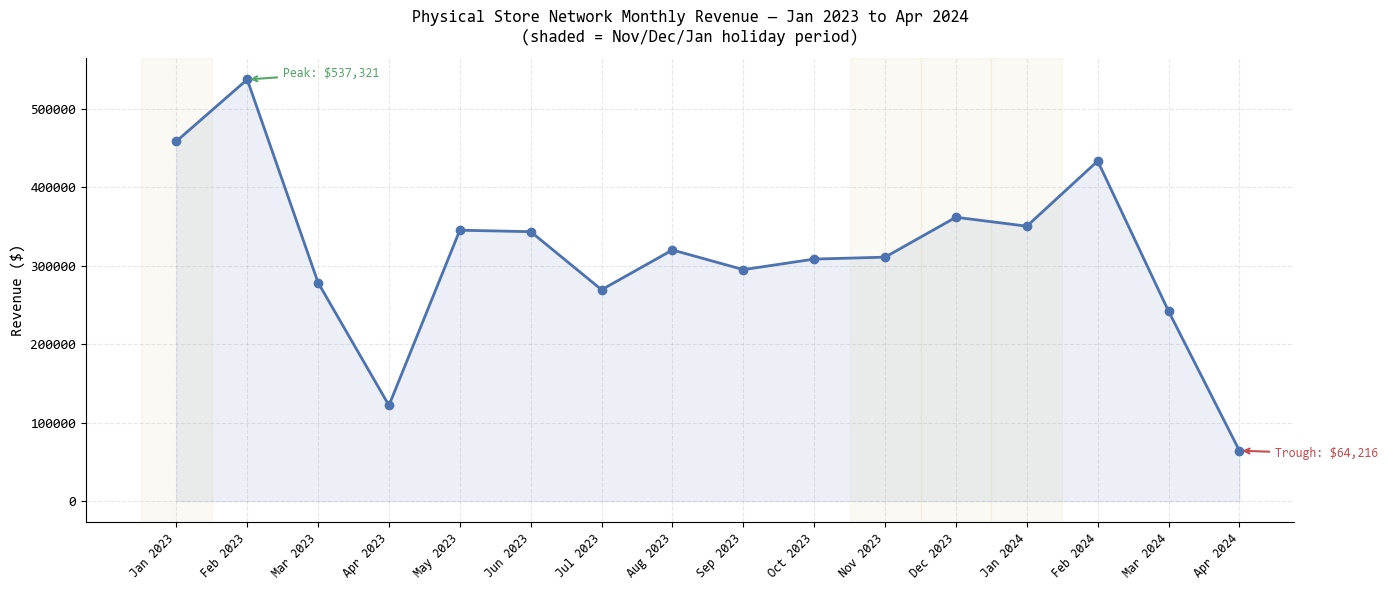

In [ ]:
# 4.L2.05 - Physical store monthly revenue seasonality Jan 2023 - Apr 2024
df_seasonal = pd.read_sql("""
    SELECT
        YEAR(s.OrderDate) AS Year,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE s.OrderDate BETWEEN '2023-01-01' AND '2024-04-30'
      AND st.CountryName != 'Online'
    GROUP BY YEAR(s.OrderDate), MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate)
    ORDER BY Year, MonthNum
""", cnxn)

df_seasonal['Period'] = df_seasonal['MonthName'].str[:3] + ' ' + df_seasonal['Year'].astype(str)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_seasonal))
ax.plot(x, df_seasonal['Revenue'], marker='o', color='#4C72B0', linewidth=2, markersize=6)
ax.fill_between(x, df_seasonal['Revenue'], alpha=0.1, color='#4C72B0')

peak_idx = df_seasonal['Revenue'].idxmax()
trough_idx = df_seasonal['Revenue'].idxmin()
ax.annotate(f"Peak: ${df_seasonal.loc[peak_idx,'Revenue']:,.0f}", 
            xy=(peak_idx, df_seasonal.loc[peak_idx,'Revenue']),
            xytext=(peak_idx+0.5, df_seasonal.loc[peak_idx,'Revenue']+3000),
            fontsize=9, color='#55A868', fontfamily='Consolas',
            arrowprops=dict(arrowstyle='->', color='#55A868', lw=1.5))
ax.annotate(f"Trough: ${df_seasonal.loc[trough_idx,'Revenue']:,.0f}",
            xy=(trough_idx, df_seasonal.loc[trough_idx,'Revenue']),
            xytext=(trough_idx+0.5, df_seasonal.loc[trough_idx,'Revenue']-8000),
            fontsize=9, color='#C44E52', fontfamily='Consolas',
            arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5))

# Shade Nov-Jan holiday period
for i, row in df_seasonal.iterrows():
    if row['MonthNum'] in [11, 12, 1]:
        ax.axvspan(i-0.5, i+0.5, alpha=0.08, color='#CCB974')

ax.set_xticks(list(x))
ax.set_xticklabels(df_seasonal['Period'].tolist(), rotation=45, ha='right', fontsize=9)
ax.set_title('Physical Store Network Monthly Revenue — Jan 2023 to Apr 2024\n(shaded = Nov/Dec/Jan holiday period)', 
             fontsize=12, fontfamily='Consolas', pad=12)
ax.set_ylabel('Revenue ($)', fontsize=11)
plt.tight_layout()
plt.show()

### Key Insight — 4.L2.05
**The physical store network follows a sharp W-shaped pattern: Feb 2023 peaks at $537K, collapses to $124K in April (a -77% drop), recovers through summer, then crashes again to $64K in April 2024 — the lowest month in the 16-month window.**
The spring trough (April) is deeply structural — April 2023 and April 2024 are both the lowest months of their respective years, at roughly one-fifth of the Feb/March peak. This consistent collapse means April is the network's most vulnerable trading month.
Operations teams should frontload promotions, inventory reductions, and staffing cost optimisation in the March-April window. The Feb 2024 peak ($433K) fell significantly short of Feb 2023 ($537K), indicating the recovery cycle is weakening year-on-year.

> **Analysis Limitation:** Data ends April 20, 2024 — the April 2024 figure covers only the first 20 days and is not directly comparable to other full months. The true April 2024 total would be approximately 50% higher if extrapolated.

---
### 4.L3.02 — 3-Month Revenue Trend by Store

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Total Revenue (M01) |
| **When** | Feb–Apr 2024 vs. Nov 2023 – Jan 2024 |
| **Where** | By individual store |
| **Why** | Identify stores with momentum vs. stores losing ground before Q2 |
| **How** | 3-month revenue change per store, ranked by absolute change |

**Full question:** For each individual store, how did total revenue in Feb–Apr 2024 compare to Nov 2023 – Jan 2024, and which stores showed the largest absolute revenue change in either direction?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Absolute revenue change (not just %) highlights which stores matter most to the network P&L.
**Grain:** One row per store, comparing two 3-month windows.

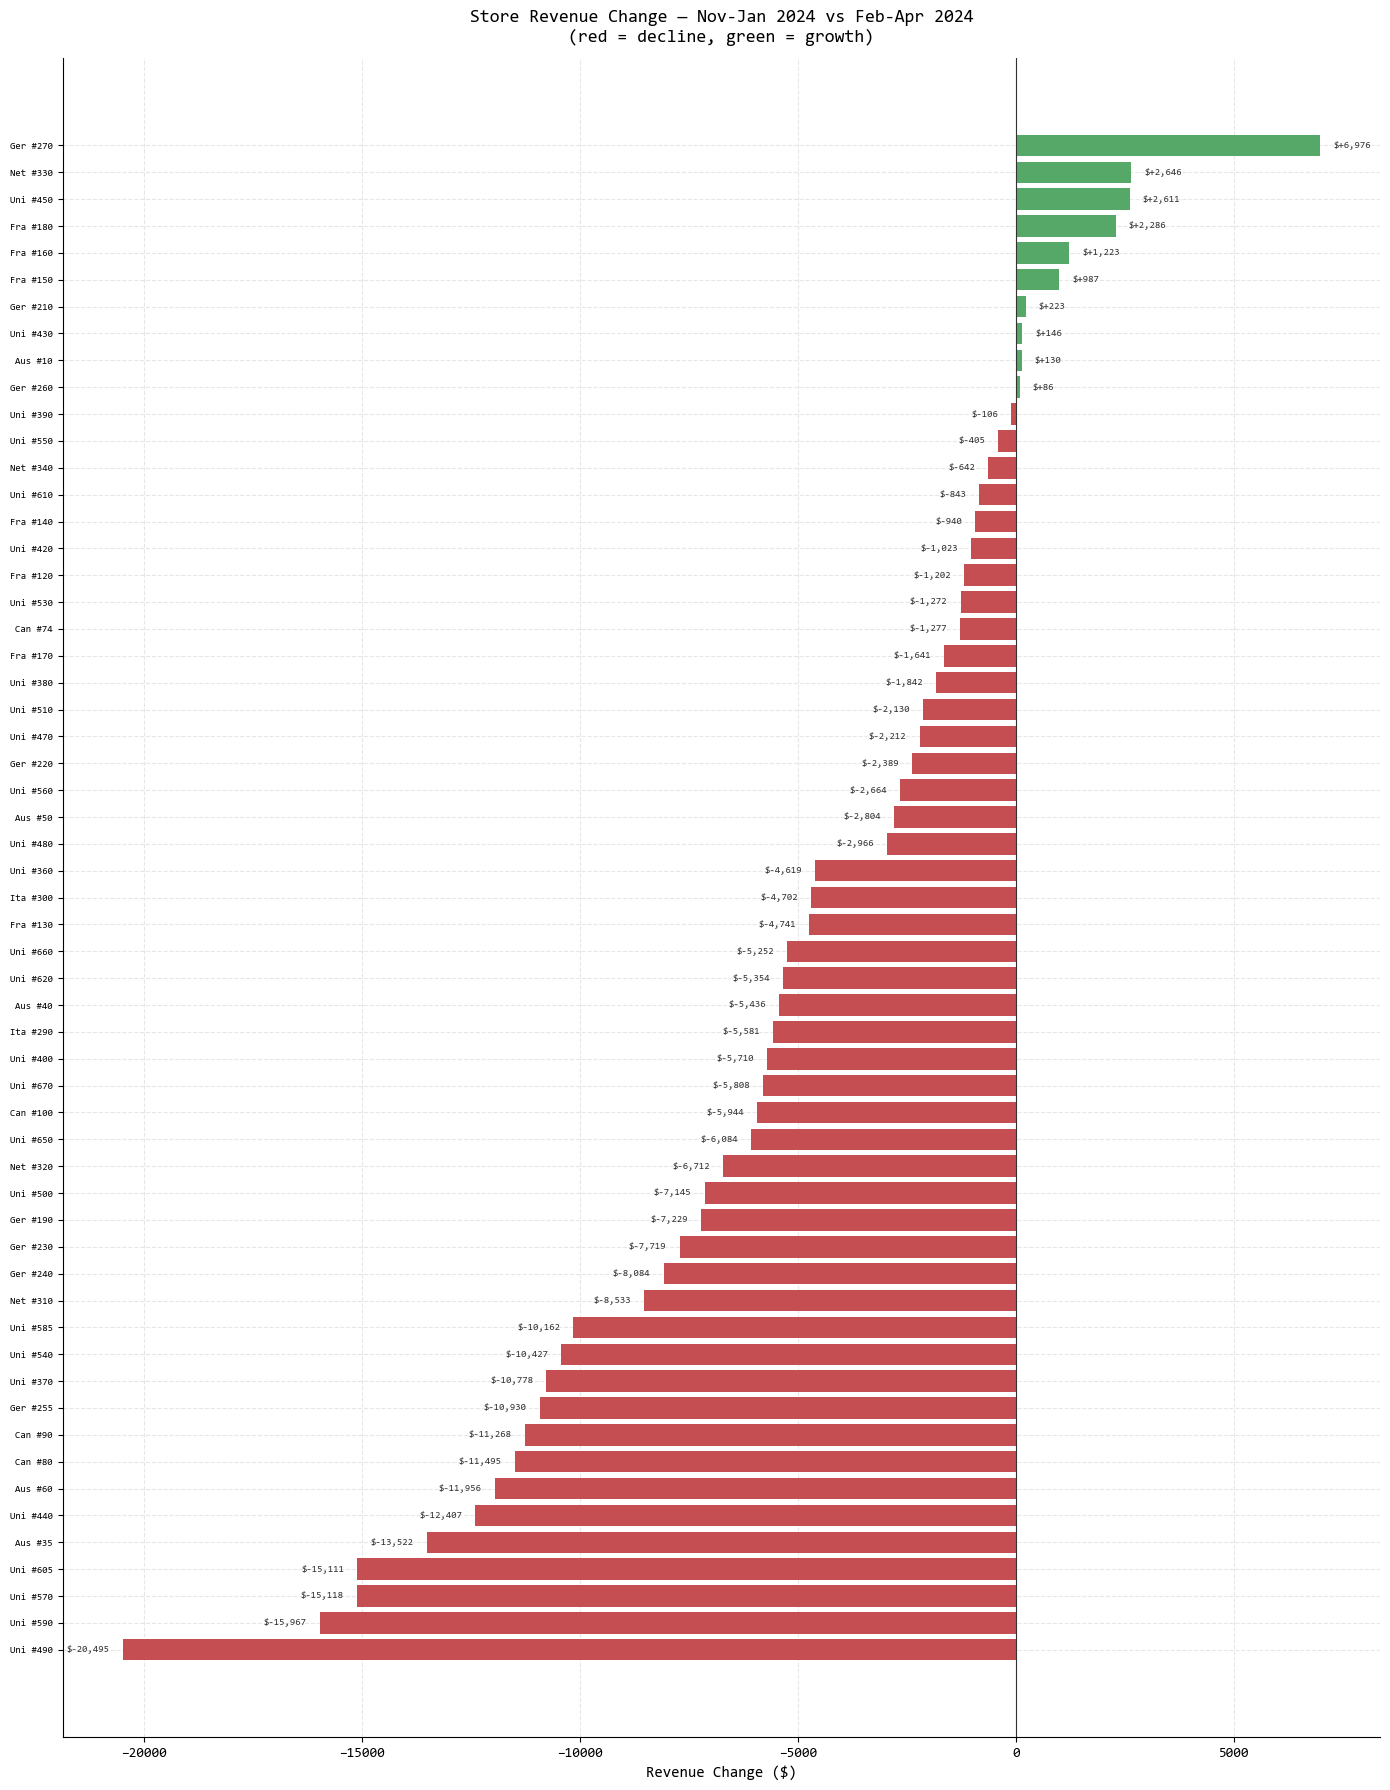

Growing stores (Feb-Apr vs Nov-Jan):
   Label    Change  ChangePct
Ger #270 6976.1393  45.722436
Net #330 2645.7519  22.456564
Uni #450 2610.7955  20.634650
Fra #180 2285.5368  35.556940
Fra #160 1222.6299  64.479751
Fra #150  986.8047  77.485692
Ger #210  223.2452   1.515793
Uni #430  146.0211   0.987234
 Aus #10  130.1570   2.209997
Ger #260   86.3341   0.539205


In [ ]:
# 4.L3.02 - 3-month revenue trend by store (absolute change)
# df_trend already computed in 4.L2.02, reuse it
df_l3_02 = df_trend.copy()
df_l3_02['Label'] = df_l3_02['CountryName'].str[:3] + ' #' + df_l3_02['StoreKey'].astype(str)
df_l3_02 = df_l3_02.sort_values('Change', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 18))
colors = ['#C44E52' if v < 0 else '#55A868' for v in df_l3_02['Change']]
bars = ax.barh(df_l3_02['Label'], df_l3_02['Change'], color=colors)
ax.axvline(0, color='#333333', linewidth=0.8)
for bar, v in zip(bars, df_l3_02['Change']):
    ha = 'right' if v < 0 else 'left'
    offset = -300 if v < 0 else 300
    ax.text(v + offset, bar.get_y()+bar.get_height()/2,
            f'${v:+,.0f}', ha=ha, va='center', fontsize=7, color='#333333', fontfamily='Consolas')
ax.set_title('Store Revenue Change — Nov-Jan 2024 vs Feb-Apr 2024\n(red = decline, green = growth)',
             fontsize=13, fontfamily='Consolas', pad=12)
ax.set_xlabel('Revenue Change ($)', fontsize=11)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

growers = df_l3_02[df_l3_02['Change']>0][['Label','Change','ChangePct']].sort_values('Change', ascending=False)
print("Growing stores (Feb-Apr vs Nov-Jan):")
print(growers.to_string(index=False))

### Key Insight — 4.L3.02
**Iowa #490 is the biggest absolute revenue loser (-$20,405), followed by Oregon #590 (-$15,967), Nebraska #605, and US #570 — the US accounts for the heaviest dollar-value declines. Only 10 stores grew, led by Germany #270 (+$6,976) which is the single standout momentum store in the network.**
France is the only country with multiple growing stores (3 out of 7 French stores grew), making it a relative bright spot in an otherwise declining physical estate.
The 10 growing stores should be interviewed for operational learnings — Germany #270's +46% swing and La Reunion/Martinique's strong gains from a low base may reflect local marketing activity or competitor closures worth documenting.

> **Analysis Limitation:** Nov-Jan includes peak holiday trading, making any store comparison across this window structurally biased toward declines. Stores that grew despite this seasonal headwind are genuinely outperforming.

---
### 4.L3.03 — YoY Revenue by Store

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Total Revenue (M01), YoY Change % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By individual store |
| **Why** | Track each store's year-on-year revenue trajectory on the same time window |
| **How** | Revenue per store for Jan-Apr 2023 vs Jan-Apr 2024, coloured by YoY direction |

**Full question:** For each physical store, what was the year-on-year revenue change between Jan–Apr 2023 and Jan–Apr 2024, and which stores improved or declined the most?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** YoY comparison on the same trading window removes seasonal bias and gives a clean store-level performance signal.
**Grain:** One row per store per year, bounded to Jan-Apr.

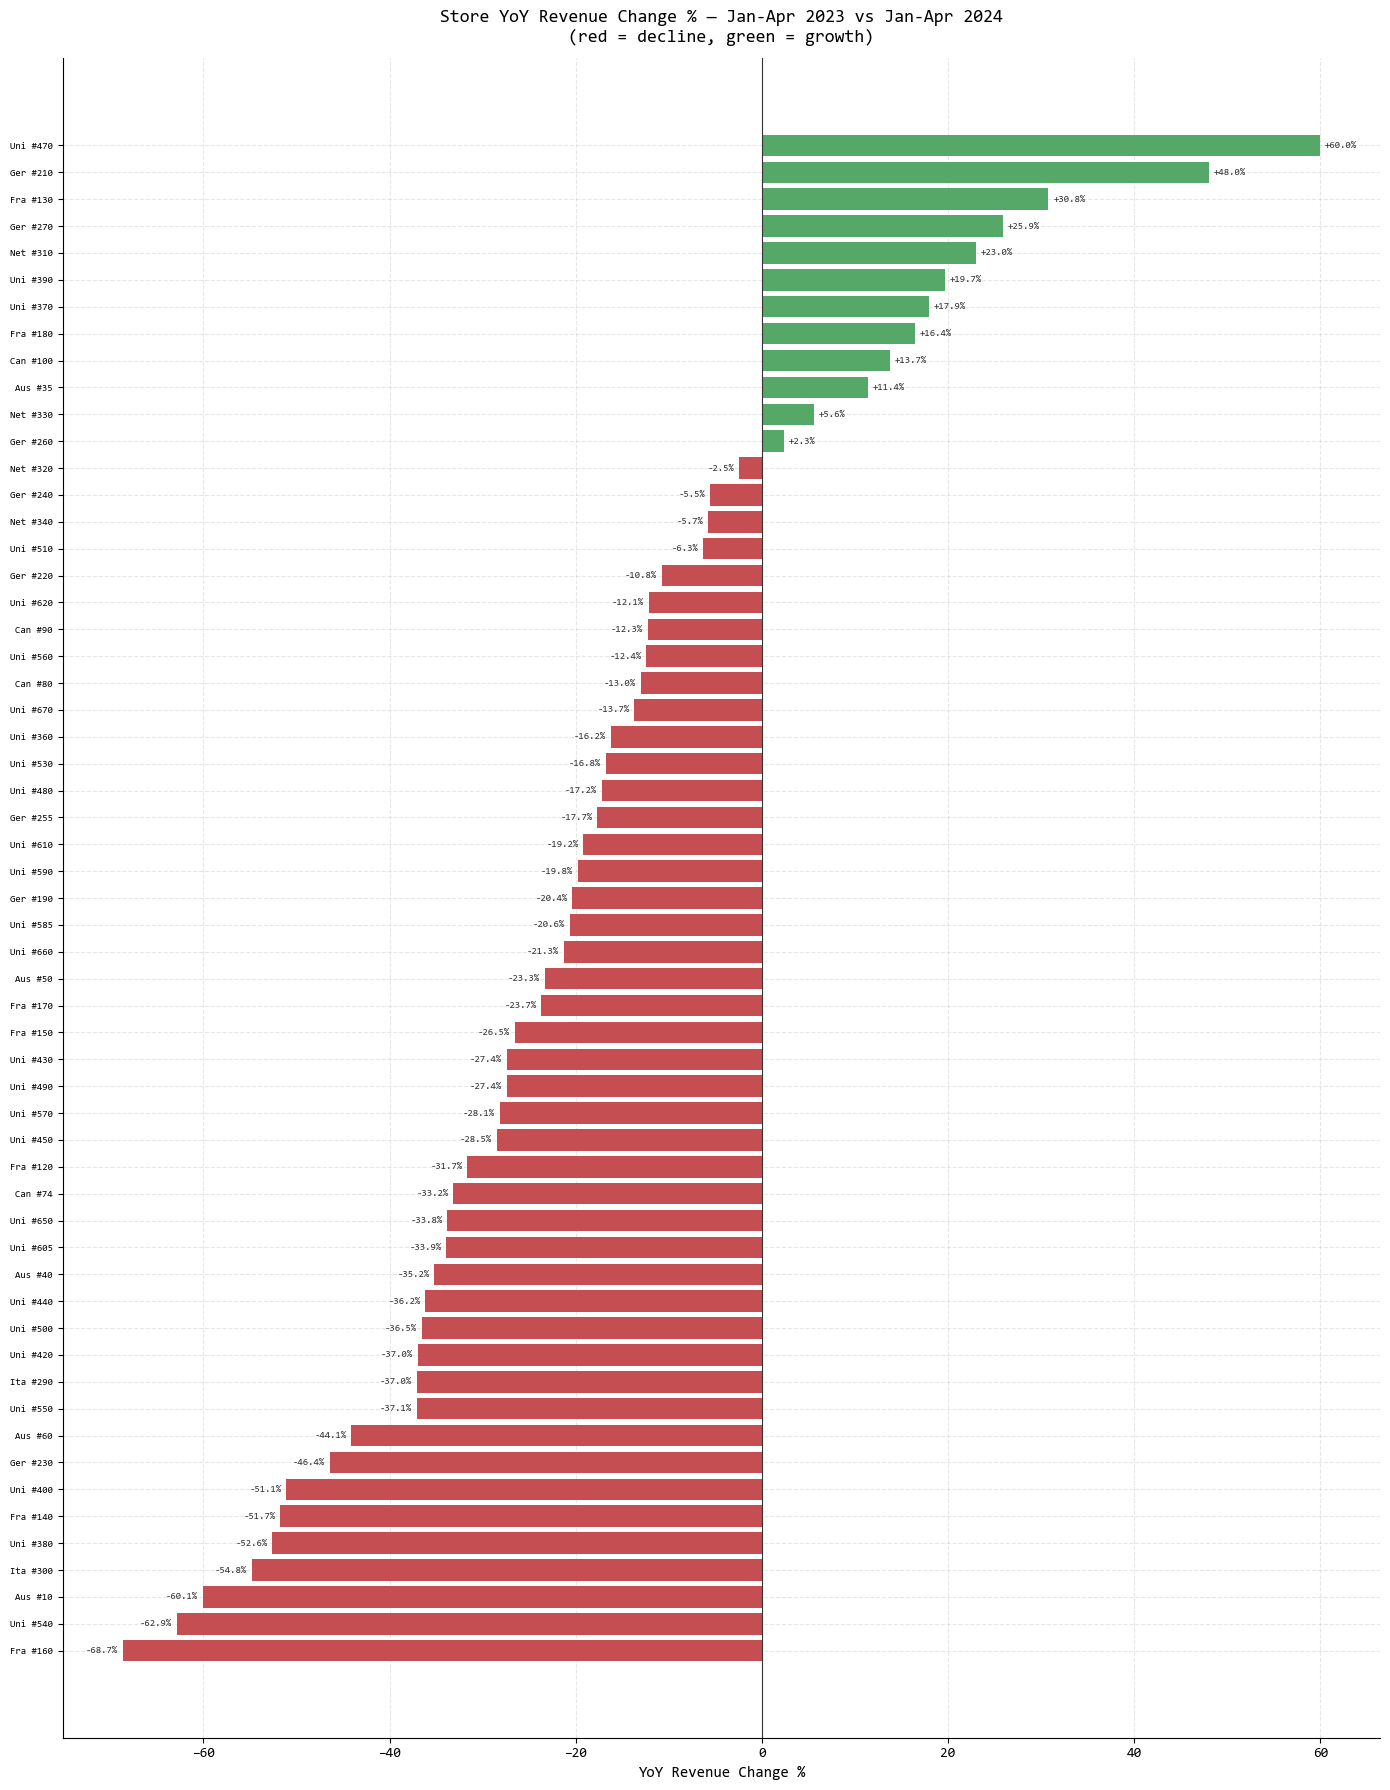

Stores with YoY growth: 12
Stores with YoY decline: 45
Median YoY change: -20.4%


In [ ]:
# 4.L3.03 - YoY revenue by store Jan-Apr 2023 vs 2024
df_yoy_store = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.State,
        SUM(CASE WHEN YEAR(s.OrderDate)=2023 THEN s.NetPrice ELSE 0 END) AS Rev2023,
        SUM(CASE WHEN YEAR(s.OrderDate)=2024 THEN s.NetPrice ELSE 0 END) AS Rev2024
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
      AND st.CountryName != 'Online'
    GROUP BY st.StoreKey, st.CountryName, st.State
    HAVING SUM(CASE WHEN YEAR(s.OrderDate)=2023 THEN s.NetPrice ELSE 0 END) > 0
""", cnxn)

df_yoy_store['YoY_Chg'] = df_yoy_store['Rev2024'] - df_yoy_store['Rev2023']
df_yoy_store['YoY_Pct'] = df_yoy_store['YoY_Chg'] / df_yoy_store['Rev2023'] * 100
df_yoy_store['Label'] = df_yoy_store['CountryName'].str[:3] + ' #' + df_yoy_store['StoreKey'].astype(str)
df_yoy_store = df_yoy_store.sort_values('YoY_Pct', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 18))
colors = ['#C44E52' if v < 0 else '#55A868' for v in df_yoy_store['YoY_Pct']]
bars = ax.barh(df_yoy_store['Label'], df_yoy_store['YoY_Pct'], color=colors)
ax.axvline(0, color='#333333', linewidth=0.8)
for bar, v in zip(bars, df_yoy_store['YoY_Pct']):
    ha = 'right' if v < 0 else 'left'
    offset = -0.5 if v < 0 else 0.5
    ax.text(v + offset, bar.get_y()+bar.get_height()/2,
            f'{v:+.1f}%', ha=ha, va='center', fontsize=7, color='#333333', fontfamily='Consolas')
ax.set_title('Store YoY Revenue Change % — Jan-Apr 2023 vs Jan-Apr 2024\n(red = decline, green = growth)',
             fontsize=13, fontfamily='Consolas', pad=12)
ax.set_xlabel('YoY Revenue Change %', fontsize=11)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

print(f"Stores with YoY growth: {(df_yoy_store['YoY_Pct']>0).sum()}")
print(f"Stores with YoY decline: {(df_yoy_store['YoY_Pct']<0).sum()}")
print(f"Median YoY change: {df_yoy_store['YoY_Pct'].median():.1f}%")

### Key Insight — 4.L3.03
**45 of 57 physical stores (79%) declined YoY, with a median drop of -20.4% — confirming the network-wide deterioration is systemic, not isolated to a few underperformers. Only 12 stores grew YoY.**
US #470 is the standout grower at +60.6%, followed by Germany #210 (+48.9%) and France #130 (+30.8%) — these three stores have nearly doubled their Jan-Apr revenue YoY and represent genuine pockets of momentum worth studying for best practices.
At the other end, France #160 (-68.7%), US #540 (-62.9%), and Australia #10 (-60.1%) lost more than 60% of revenue YoY — these stores require immediate investigation as they may be approaching unviability.

> **Analysis Limitation:** This comparison is fair (same Jan-Apr window both years) but does not account for local economic conditions, competitor activity, or store-specific events that may explain outlier performance.

---
### 4.L3.04 — Revenue per sqm by Store Ranked

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Revenue per Square Meter (M11) |
| **When** | Jan–Apr 2024 |
| **Where** | All physical stores, ranked |
| **Why** | Identify lowest-productivity stores for operational review |
| **How** | Full ranked list of revenue per sqm across all physical stores |

**Full question:** What is the complete ranked list of physical stores by revenue per square meter in Jan–Apr 2024, and which stores fall below a critical productivity threshold?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** A ranked list gives operations managers a clear priority order for footprint review conversations.
**Grain:** One row per store, Jan-Apr 2024.

In [ ]:
# 4.L3.04 - Revenue per sqm ranked (reuse df_sqm_24 from 4.L2.03)
import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

threshold = 7.0  # below this is critical
ranked = df_sqm_24.sort_values('RevPerSqm', ascending=True).copy()
ranked['FullLabel'] = ranked['CountryName'] + ' ' + ranked['State'].fillna('') + ' #' + ranked['StoreKey'].astype(str)

fig, ax = plt.subplots(figsize=(14, 20))
colors = ['#C44E52' if v < threshold else ('#DD8452' if v < network_avg else '#4C72B0') for v in ranked['RevPerSqm']]
bars = ax.barh(ranked['FullLabel'], ranked['RevPerSqm'], color=colors)
ax.axvline(threshold, color='#C44E52', linewidth=1.2, linestyle=':', label=f'Critical threshold ${threshold:.0f}/sqm')
ax.axvline(network_avg, color='#DD8452', linewidth=1.2, linestyle='--', label=f'Network avg ${network_avg:.2f}/sqm')
for bar, v in zip(bars, ranked['RevPerSqm']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'${v:.1f}', ha='left', va='center', fontsize=6.5, color='#333333', fontfamily='Consolas')
ax.set_title('Physical Store Revenue per sqm — Ranked Jan-Apr 2024\n(red = below $7/sqm critical, orange = below network avg)',
             fontsize=12, fontfamily='Consolas', pad=12)
ax.set_xlabel('Revenue per sqm ($)', fontsize=10)
ax.tick_params(axis='y', labelsize=7)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

below_critical = (ranked['RevPerSqm'] < threshold).sum()
print(f"Stores below ${threshold:.0f}/sqm critical threshold: {below_critical}")
print(f"Stores below network avg ${network_avg:.2f}/sqm: {(ranked['RevPerSqm'] < network_avg).sum()}")

KeyError: 'State'

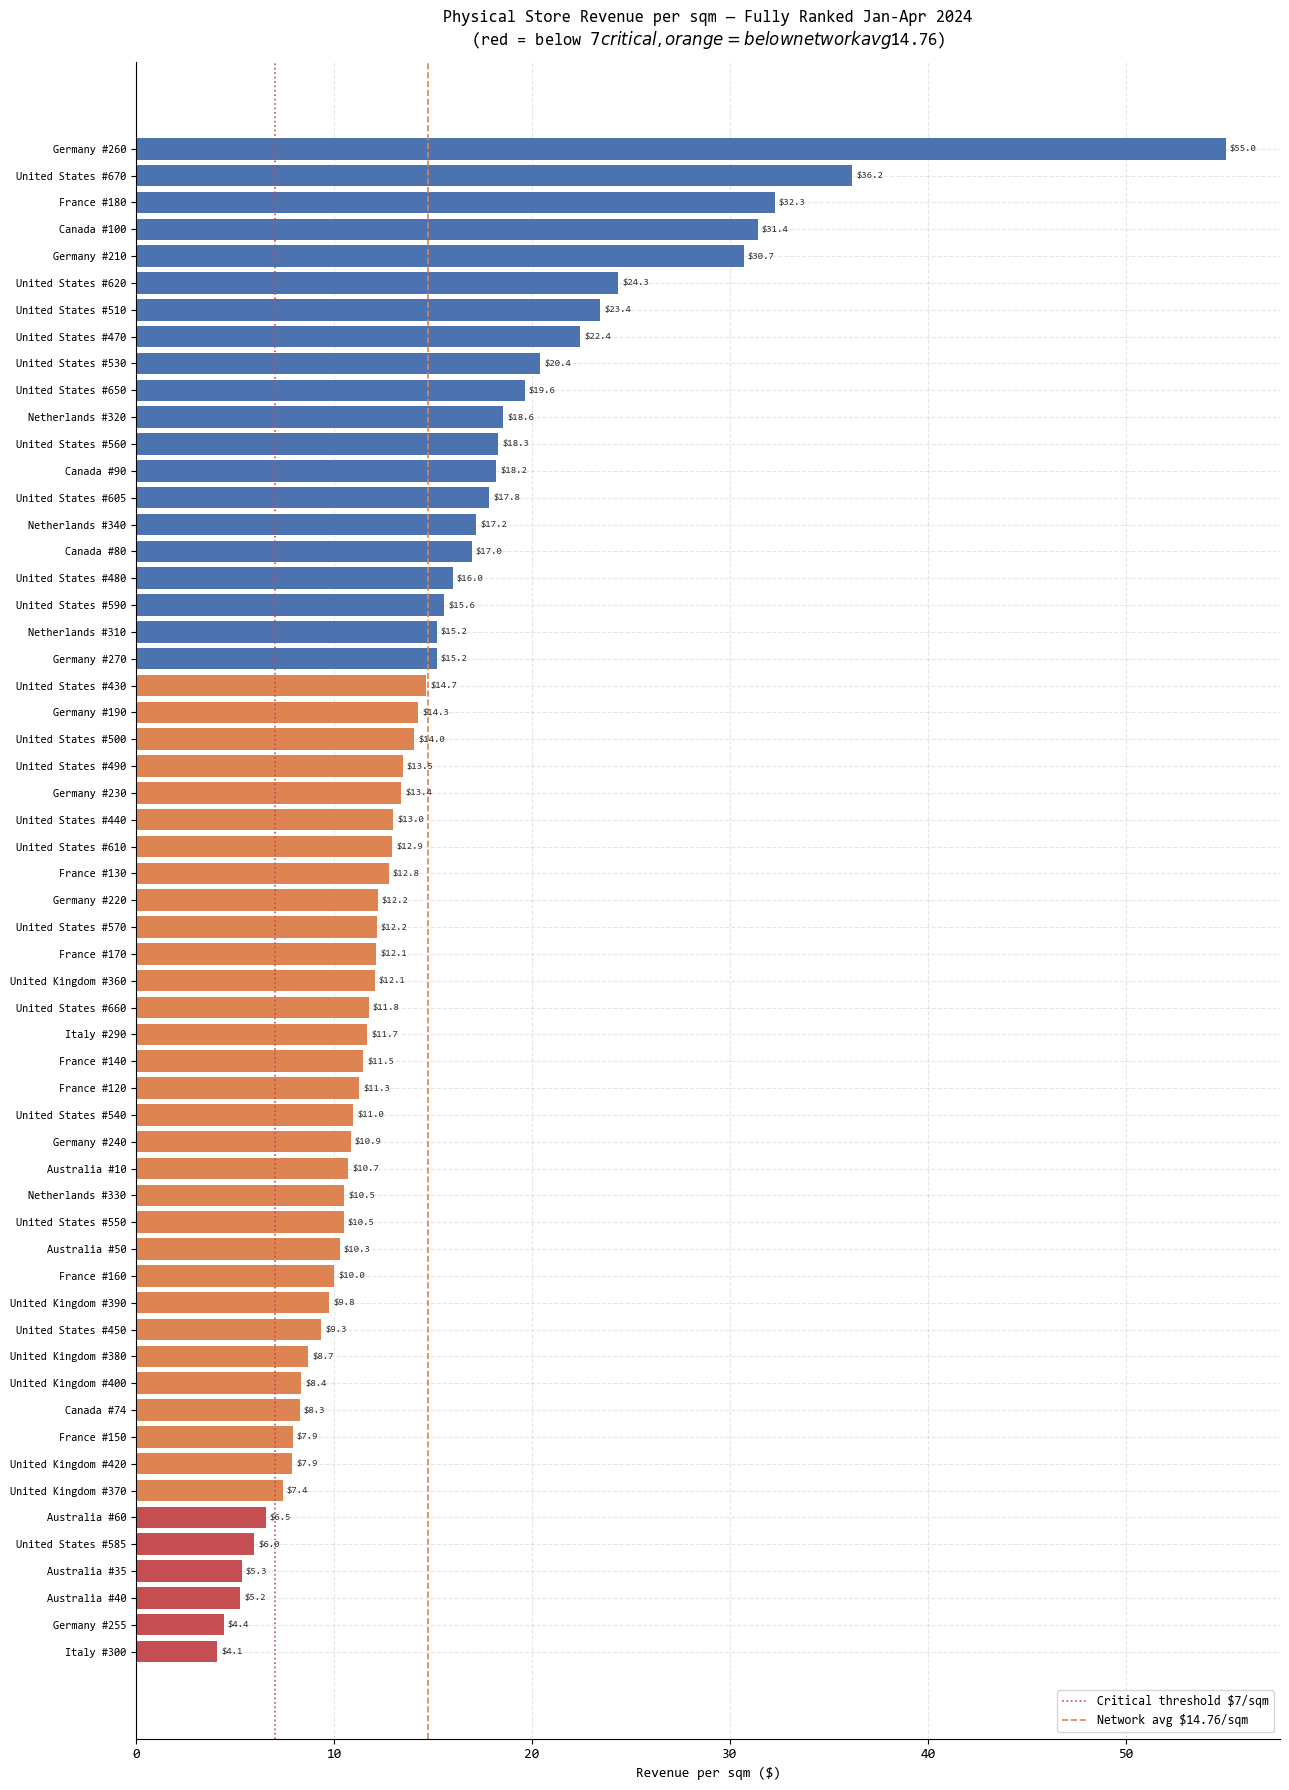

Stores below $7/sqm: 6
Stores below network avg: 37


In [ ]:
# 4.L3.04 - Revenue per sqm ranked (fixed labels)
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

threshold = 7.0
ranked = df_sqm_24.sort_values('RevPerSqm', ascending=True).copy()
ranked['FullLabel'] = ranked['CountryName'] + ' #' + ranked['StoreKey'].astype(str)

fig, ax = plt.subplots(figsize=(13, 18))
colors = ['#C44E52' if v < threshold else ('#DD8452' if v < network_avg else '#4C72B0') for v in ranked['RevPerSqm']]
bars = ax.barh(ranked['FullLabel'], ranked['RevPerSqm'], color=colors)
ax.axvline(threshold, color='#C44E52', linewidth=1.2, linestyle=':', label=f'Critical threshold ${threshold:.0f}/sqm')
ax.axvline(network_avg, color='#DD8452', linewidth=1.2, linestyle='--', label=f'Network avg ${network_avg:.2f}/sqm')
for bar, v in zip(bars, ranked['RevPerSqm']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'${v:.1f}', ha='left', va='center', fontsize=7, color='#333333', fontfamily='Consolas')
ax.set_title('Physical Store Revenue per sqm — Fully Ranked Jan-Apr 2024\n(red = below $7 critical, orange = below network avg $14.76)',
             fontsize=12, fontfamily='Consolas', pad=12)
ax.set_xlabel('Revenue per sqm ($)', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

below_critical = (ranked['RevPerSqm'] < threshold).sum()
print(f"Stores below ${threshold:.0f}/sqm: {below_critical}")
print(f"Stores below network avg: {(ranked['RevPerSqm'] < network_avg).sum()}")

### Key Insight — 4.L3.04
**6 stores fall below the $7/sqm critical threshold (Italy #300, Germany #255, Australia #40/#35, US #585, and Australia #60), and 37 of 57 stores (65%) are below the $14.76 network average — meaning underperformance is the majority state, not the exception.**
Germany #260 towers at $55/sqm — nearly 4x the network average and 13x the lowest store — representing the best-in-class benchmark for what the Contoso store model can achieve.
The 6 critical stores (below $7/sqm) should enter formal review for lease renegotiation or closure; at annualised rates below ~$21/sqm they are almost certainly unprofitable given typical retail occupancy costs.

> **Analysis Limitation:** The $7/sqm threshold is illustrative — the actual break-even point per store depends on lease cost, headcount, and local cost of living which are not available in this dataset.

---
### 4.L3.05 — Revenue per sqm by Country Average

| Lens | Value |
|---|---|
| **Who** | P3 — Head of Retail Expansion |
| **What** | Revenue per Square Meter (M11) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country, physical stores |
| **Why** | Compare country-level space efficiency to prioritise expansion vs. rationalisation |
| **How** | Average revenue per sqm by country for both years, with YoY change |

**Full question:** How does the average revenue per square meter compare across countries in Jan–Apr 2024 vs. Jan–Apr 2023 — and which countries improved their store space efficiency year-on-year?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Country-level sqm productivity drives expansion strategy — markets with rising productivity justify new store investment.
**Grain:** One row per country per year, Jan-Apr window.

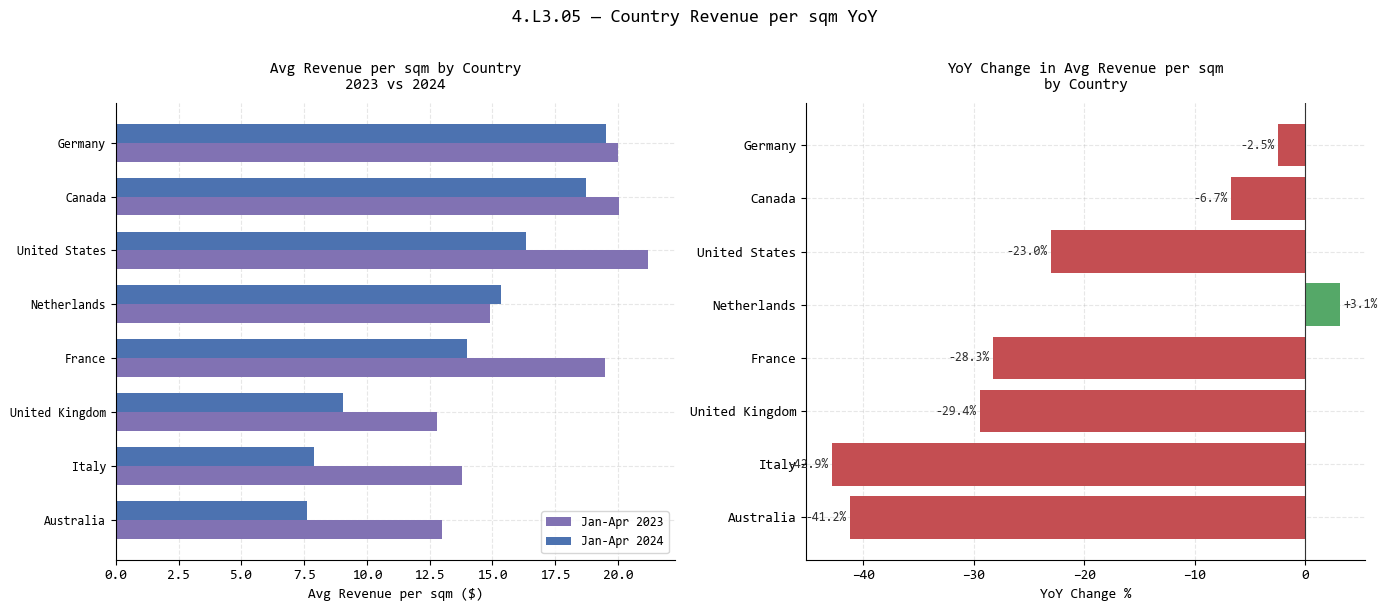

   CountryName   Avg2023   Avg2024    YoY_Pct
     Australia 12.973538  7.629269 -41.193613
         Italy 13.803492  7.885039 -42.876491
United Kingdom 12.803920  9.033699 -29.445837
        France 19.483141 13.974107 -28.275907
   Netherlands 14.892259 15.360342   3.143131
 United States 21.207739 16.329673 -23.001350
        Canada 20.062642 18.712941  -6.727434
       Germany 20.004215 19.506982  -2.485639


In [ ]:
# 4.L3.05 - Country avg revenue per sqm YoY comparison
# Use df_store_sqm which has both years
country_sqm_yoy = df_store_sqm.groupby(['CountryName','Year'])['RevPerSqm'].mean().reset_index()
pivot = country_sqm_yoy.pivot(index='CountryName', columns='Year', values='RevPerSqm').reset_index()
pivot.columns.name = None
pivot.columns = ['CountryName', 'Avg2023', 'Avg2024']
pivot['YoY_Chg'] = pivot['Avg2024'] - pivot['Avg2023']
pivot['YoY_Pct'] = pivot['YoY_Chg'] / pivot['Avg2023'] * 100
pivot = pivot.sort_values('Avg2024', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
import numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grouped bar: 2023 vs 2024 by country
ax = axes[0]
x = np.arange(len(pivot))
w = 0.35
b1 = ax.barh(x - w/2, pivot['Avg2023'], height=w, color='#8172B3', label='Jan-Apr 2023')
b2 = ax.barh(x + w/2, pivot['Avg2024'], height=w, color='#4C72B0', label='Jan-Apr 2024')
ax.set_yticks(x)
ax.set_yticklabels(pivot['CountryName'], fontsize=9)
ax.legend(fontsize=9)
ax.set_title('Avg Revenue per sqm by Country\n2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_xlabel('Avg Revenue per sqm ($)', fontsize=10)

# YoY % change
ax2 = axes[1]
colors = ['#55A868' if v >= 0 else '#C44E52' for v in pivot['YoY_Pct']]
bars = ax2.barh(pivot['CountryName'], pivot['YoY_Pct'], color=colors)
ax2.axvline(0, color='#333333', linewidth=0.8)
for bar, v in zip(bars, pivot['YoY_Pct']):
    ha = 'right' if v < 0 else 'left'
    offset = -0.3 if v < 0 else 0.3
    ax2.text(v + offset, bar.get_y()+bar.get_height()/2,
             f'{v:+.1f}%', ha=ha, va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax2.set_title('YoY Change in Avg Revenue per sqm\nby Country', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('YoY Change %', fontsize=10)

plt.suptitle('4.L3.05 — Country Revenue per sqm YoY', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(pivot[['CountryName','Avg2023','Avg2024','YoY_Pct']].to_string(index=False))

### Key Insight — 4.L3.05
**Netherlands is the ONLY country where store productivity improved YoY (+3.1%), while every other market declined — Italy (-42.9%) and Australia (-41.2%) suffered the steepest collapses, losing nearly half their revenue per sqm in one year.**
Germany and Canada are the most resilient markets, holding their productivity close to 2023 levels (-2.5% and -6.7% respectively) — these markets should be the primary focus for new store investment if expansion resumes.
Italy and Australia's stores are now generating below $8/sqm on average — dangerously close to break-even territory. A country-level strategic review is warranted for both markets.

> **Analysis Limitation:** Country averages are unweighted means across stores (not weighted by store size), so a few large or small outlier stores in small-count countries (Italy has only 3 stores) can skew the average significantly.

---
### 4.L3.06 — Store Age vs. Revenue per sqm

| Lens | Value |
|---|---|
| **Who** | P3 — Head of Retail Expansion |
| **What** | Revenue per Square Meter (M11), Store age (years) |
| **When** | Jan–Apr 2024 |
| **Where** | All physical stores |
| **Why** | Understand if older stores are more productive (experience effect) or less (obsolescence) |
| **How** | Scatter plot of store age (years since open) vs revenue per sqm |

**Full question:** Is there a relationship between store age (years since opening) and revenue per square meter in Jan–Apr 2024 — do older stores perform better or worse than newer ones?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** If older stores decline, a scheduled refresh/renovation programme may be justified.
**Grain:** One row per store, Jan-Apr 2024.

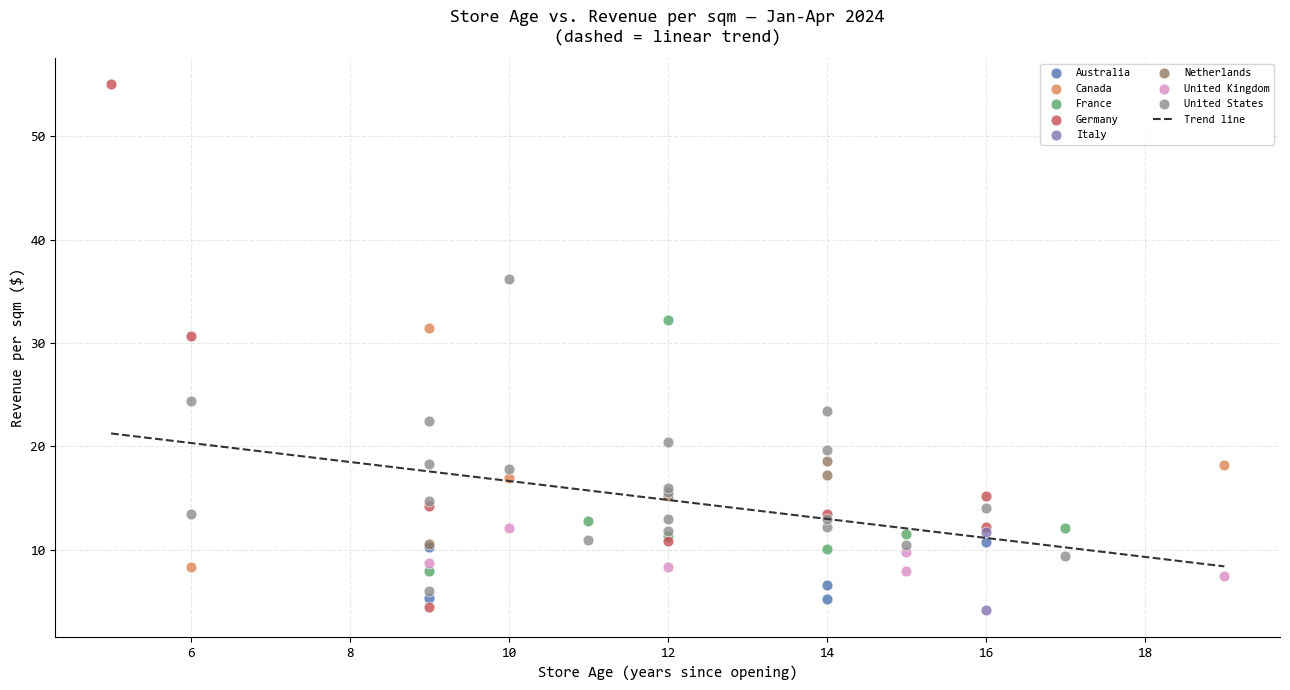

Pearson correlation (age vs rev/sqm): -0.353


In [ ]:
# 4.L3.06 - Store age vs revenue per sqm (scatter)
df_age_sqm = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        st.SquareMeters,
        st.OpenDate,
        DATEDIFF(YEAR, st.OpenDate, '2024-01-01') AS StoreAgeYears,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
      AND st.SquareMeters > 0
    GROUP BY st.StoreKey, st.CountryName, st.SquareMeters, st.OpenDate
""", cnxn)
df_age_sqm['RevPerSqm'] = df_age_sqm['Revenue'] / df_age_sqm['SquareMeters']

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C","#CCB974"]
countries = df_age_sqm['CountryName'].unique()
country_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(sorted(countries))}

fig, ax = plt.subplots(figsize=(13, 7))
for country in sorted(countries):
    sub = df_age_sqm[df_age_sqm['CountryName']==country]
    ax.scatter(sub['StoreAgeYears'], sub['RevPerSqm'],
               color=country_colors[country], label=country, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

# Trend line
x_vals = df_age_sqm['StoreAgeYears'].values
y_vals = df_age_sqm['RevPerSqm'].values
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, p(x_line), color='#333333', linewidth=1.5, linestyle='--', label='Trend line')

ax.set_title('Store Age vs. Revenue per sqm — Jan-Apr 2024\n(dashed = linear trend)', fontsize=13, fontfamily='Consolas', pad=12)
ax.set_xlabel('Store Age (years since opening)', fontsize=11)
ax.set_ylabel('Revenue per sqm ($)', fontsize=11)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

corr = np.corrcoef(x_vals, y_vals)[0,1]
print(f"Pearson correlation (age vs rev/sqm): {corr:.3f}")

### Key Insight — 4.L3.06
**There is a moderate negative correlation (r = -0.35) between store age and revenue per sqm — meaning older stores tend to generate less revenue per square metre, suggesting a store ageing/obsolescence effect.**
The youngest stores (5-6 years old) include the highest performers in the network — Germany #260 ($55/sqm at 5 years old) and Germany #210 at 6 years old. However, the scatter is wide, meaning age is not a clean predictor: some 16-year-old stores still outperform stores half their age.
Operations should investigate whether stores in this estate have been renovated — if not, a scheduled refresh programme for the oldest tercile could recover meaningful productivity without the capital cost of new openings.

> **Analysis Limitation:** The dataset covers stores aged 5-19 years with no stores under 5 years (no new openings). The correlation may reflect macro/market trends (Contoso opened more stores in higher-potential locations in certain vintages) rather than a true ageing effect.

---
### 4.L3.07 — New vs. Mature Store Productivity Comparison

| Lens | Value |
|---|---|
| **Who** | P3 — Head of Retail Expansion |
| **What** | Revenue per Square Meter (M11), Total Revenue (M01) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | Physical stores segmented by age group |
| **Why** | Understand if older store cohorts are declining faster than younger ones |
| **How** | Revenue per sqm YoY change broken down by store age tertile |

**Full question:** Do stores in different age groups show different rates of revenue per sqm decline from Jan–Apr 2023 to Jan–Apr 2024, and which age cohort is deteriorating fastest?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** If older stores are declining faster, a renovation/closure programme should be targeted at the oldest cohort first.
**Grain:** One row per store per year, comparing age tertiles YoY.

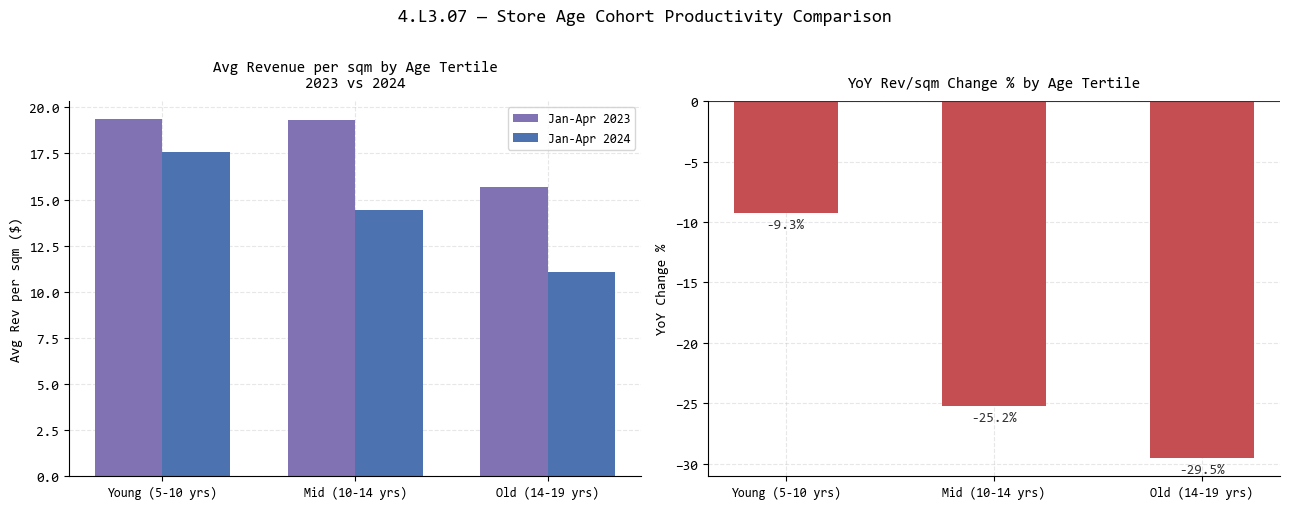

      AgeTertile   Avg2023   Avg2024    YoY_Pct
Young (5-10 yrs) 19.373538 17.574838  -9.284314
 Mid (10-14 yrs) 19.300278 14.432091 -25.223404
 Old (14-19 yrs) 15.674686 11.045134 -29.535215


In [ ]:
# 4.L3.07 - YoY rev/sqm change by store age tertile
df_cohort = df_store_sqm.copy()
# Get store open dates from df_age_sqm
age_map = df_age_sqm[['StoreKey','StoreAgeYears']].set_index('StoreKey')['StoreAgeYears']
df_cohort['StoreAgeYears'] = df_cohort['StoreKey'].map(age_map)
df_cohort = df_cohort.dropna(subset=['StoreAgeYears'])
df_cohort['AgeTertile'] = pd.qcut(df_cohort['StoreAgeYears'], q=3, labels=['Young (5-10 yrs)','Mid (10-14 yrs)','Old (14-19 yrs)'])

tertile_yoy = df_cohort.groupby(['AgeTertile','Year'])['RevPerSqm'].mean().reset_index()
pivt = tertile_yoy.pivot(index='AgeTertile', columns='Year', values='RevPerSqm').reset_index()
pivt.columns.name = None
pivt.columns = ['AgeTertile','Avg2023','Avg2024']
pivt['YoY_Pct'] = (pivt['Avg2024'] - pivt['Avg2023']) / pivt['Avg2023'] * 100

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452","#55A868"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(pivt))
w = 0.35
ax.bar(x - w/2, pivt['Avg2023'], width=w, color='#8172B3', label='Jan-Apr 2023')
ax.bar(x + w/2, pivt['Avg2024'], width=w, color='#4C72B0', label='Jan-Apr 2024')
ax.set_xticks(x)
ax.set_xticklabels(pivt['AgeTertile'], fontsize=9)
ax.set_title('Avg Revenue per sqm by Age Tertile\n2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_ylabel('Avg Rev per sqm ($)', fontsize=10)
ax.legend(fontsize=9)

ax2 = axes[1]
colors = ['#C44E52' if v < 0 else '#55A868' for v in pivt['YoY_Pct']]
bars = ax2.bar(pivt['AgeTertile'], pivt['YoY_Pct'], color=colors, width=0.5)
for bar, v in zip(bars, pivt['YoY_Pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height() + (0.3 if v >= 0 else -1.5),
             f'{v:+.1f}%', ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
ax2.axhline(0, color='#333333', linewidth=0.8)
ax2.set_title('YoY Rev/sqm Change % by Age Tertile', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_ylabel('YoY Change %', fontsize=10)
ax2.tick_params(axis='x', labelsize=9)

plt.suptitle('4.L3.07 — Store Age Cohort Productivity Comparison', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(pivt.to_string(index=False))

### Key Insight — 4.L3.07
**Older stores are declining significantly faster: the youngest cohort (5-10 years) fell only -9.3% YoY, while mid-age stores (10-14 years) declined -25.2% and the oldest cohort (14-19 years) dropped -29.5% — a clear age-linked deterioration gradient.**
This pattern is consistent with a store obsolescence effect: older stores are losing customers at a faster rate, potentially due to dated store formats, demographics shifts in their catchment areas, or higher online substitution rates in markets where those stores were first opened.
The operational priority is clear: the 14-19 year cohort needs immediate attention — either a targeted renovation programme to restore productivity, or closure planning for the lowest-performing stores within it.

> **Analysis Limitation:** Age tertile boundaries are data-driven (based on distribution of actual store ages) rather than business-meaningful age brackets. The gap between Young and Mid cohorts in % change is large despite similar 2023 starting points, suggesting other factors beyond age are at play.

---
### 4.L3.08 — Revenue by Store by Month

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 monthly |
| **Where** | Top 10 physical stores by total Jan-Apr 2024 revenue |
| **Why** | Show month-by-month trading trajectory for highest-revenue stores |
| **How** | Line chart of monthly revenue for top 10 stores across 4 months |

**Full question:** For the top 10 physical stores by revenue in Jan–Apr 2024, how did their monthly revenue trend across those four months — and which stores show consistent momentum vs. volatility?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Monthly store-level trends reveal volatility or momentum invisible in quarterly totals.
**Grain:** One row per store per month, top 10 stores Jan-Apr 2024.

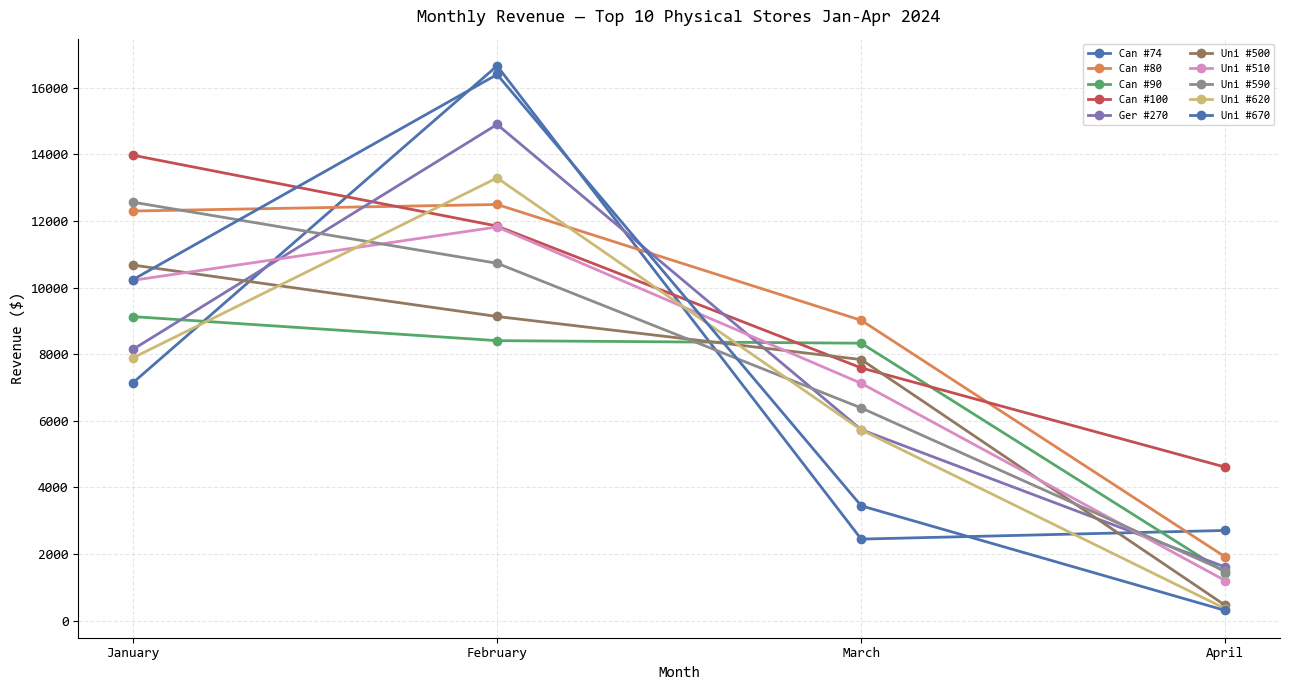

In [ ]:
# 4.L3.08 - Monthly revenue for top 10 stores Jan-Apr 2024
df_monthly_store = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
    GROUP BY st.StoreKey, st.CountryName, MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate)
""", cnxn)

top10_keys = df_monthly_store.groupby('StoreKey')['Revenue'].sum().nlargest(10).index
df_top10 = df_monthly_store[df_monthly_store['StoreKey'].isin(top10_keys)].copy()
df_top10['Label'] = df_top10['CountryName'].str[:3] + ' #' + df_top10['StoreKey'].astype(str)
df_top10 = df_top10.sort_values('MonthNum')

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C","#CCB974","#4C72B0"]
months = ['January','February','March','April']

fig, ax = plt.subplots(figsize=(13, 7))
for i, (store_key, grp) in enumerate(df_top10.groupby('StoreKey')):
    grp = grp.sort_values('MonthNum')
    label = grp['Label'].iloc[0]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(grp['MonthName'], grp['Revenue'], marker='o', label=label, color=color, linewidth=2, markersize=6)

ax.set_title('Monthly Revenue — Top 10 Physical Stores Jan-Apr 2024', fontsize=13, fontfamily='Consolas', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

### Key Insight — 4.L3.08
**All top 10 stores follow the same steep inverse-V pattern: peak in February, then sharp decline into March and April — the top-performing store Canada #74 peaked at $16.5K in February and fell to just $350 by April, a -98% intra-quarter drop.**
The uniformity of this collapse across all 10 top stores confirms this is a seasonal demand phenomenon, not a store-specific problem — physical retail for Contoso effectively shuts down in April regardless of how strong the store is.
Canada dominates the top 10 with 4 of the 10 stores (Can #74, #80, #90, #100), reinforcing its status as the strongest physical retail market in the network. Operations should front-load all Q1 campaigns toward February maximisation.

> **Analysis Limitation:** April 2024 data covers only 20 days (data ends April 20), so the April revenue figures are partial and the actual April total would be approximately 50% higher if extrapolated to a full month.

---
### 4.L3.09 — Unique Customers per Store per Month

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Unique Customer Count |
| **When** | Jan–Apr 2024 monthly |
| **Where** | Physical stores |
| **Why** | Assess footfall trends per store — declining unique customers signals a traffic problem |
| **How** | Count distinct CustomerKeys per store per month |

**Full question:** How many unique customers did each physical store serve per month in Jan–Apr 2024, and which stores are losing customer footfall most rapidly?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Revenue can decline due to fewer customers (footfall problem) or lower spend per customer (basket problem) — this metric isolates the footfall dimension.
**Grain:** One row per store per month, Jan-Apr 2024.

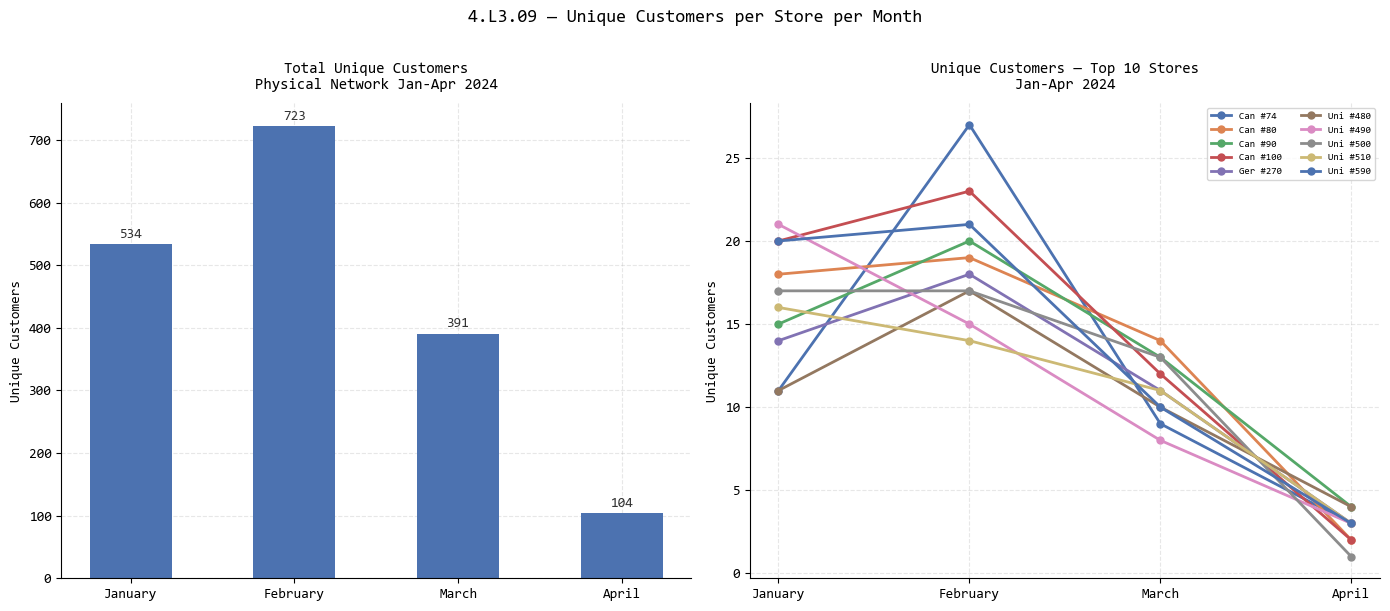

Network footfall summary:
MonthName  UniqueCustomers
  January              534
 February              723
    March              391
    April              104


In [ ]:
# 4.L3.09 - Unique customers per store per month Jan-Apr 2024
df_cust_store = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        MONTH(s.OrderDate) AS MonthNum,
        DATENAME(MONTH, s.OrderDate) AS MonthName,
        COUNT(DISTINCT s.CustomerKey) AS UniqueCustomers
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
    GROUP BY st.StoreKey, st.CountryName, MONTH(s.OrderDate), DATENAME(MONTH, s.OrderDate)
""", cnxn)

# Network totals by month
network_cust = df_cust_store.groupby(['MonthNum','MonthName'])['UniqueCustomers'].sum().reset_index().sort_values('MonthNum')

# Per-store monthly totals
store_totals = df_cust_store.groupby('StoreKey')['UniqueCustomers'].sum()
top10_cust_keys = store_totals.nlargest(10).index

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C","#CCB974","#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Network footfall by month
ax = axes[0]
ax.bar(network_cust['MonthName'], network_cust['UniqueCustomers'], color='#4C72B0', width=0.5)
for i, (mn, v) in enumerate(zip(network_cust['MonthName'], network_cust['UniqueCustomers'])):
    ax.text(i, v+5, str(v), ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')
ax.set_title('Total Unique Customers\nPhysical Network Jan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_ylabel('Unique Customers', fontsize=10)

# Top 10 stores by unique customers
ax2 = axes[1]
df_top10_cust = df_cust_store[df_cust_store['StoreKey'].isin(top10_cust_keys)].copy()
df_top10_cust['Label'] = df_top10_cust['CountryName'].str[:3] + ' #' + df_top10_cust['StoreKey'].astype(str)
for i, (sk, grp) in enumerate(df_top10_cust.groupby('StoreKey')):
    grp = grp.sort_values('MonthNum')
    ax2.plot(grp['MonthName'], grp['UniqueCustomers'], marker='o', label=grp['Label'].iloc[0],
             color=PALETTE[i % len(PALETTE)], linewidth=2, markersize=5)
ax2.set_title('Unique Customers — Top 10 Stores\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_ylabel('Unique Customers', fontsize=10)
ax2.legend(fontsize=7, ncol=2)

plt.suptitle('4.L3.09 — Unique Customers per Store per Month', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print("Network footfall summary:")
print(network_cust[['MonthName','UniqueCustomers']].to_string(index=False))

### Key Insight — 4.L3.09
**Physical store footfall peaks sharply in February (723 unique customers across the network) and collapses to just 104 in April — a -86% drop from peak to trough, confirming that the revenue decline is driven by a footfall problem, not a basket-size problem.**
The pattern is identical across all top 10 stores: the February spike is universal, meaning it is a genuine demand surge (likely Valentine's Day, tax season, or similar seasonal trigger) rather than a marketing-driven event at specific stores.
With only 104 unique customers across the entire physical network in April (partial month), Contoso's stores are effectively empty in spring. This raises a fundamental question about whether staffing and lease costs are warranted for a month where the entire network serves fewer customers than a single store in February.

> **Analysis Limitation:** Unique customers are counted per store per month — a customer buying at two stores in the same month is counted twice in the network total. April covers only 20 days so the figure underestimates the full month.

---
### 4.L3.10 — Average Delivery Lead Time by Store

| Lens | Value |
|---|---|
| **Who** | P4 — Store Operations Manager |
| **What** | Average delivery lead time (days from OrderDate to DeliveryDate) |
| **When** | Jan–Apr 2024 |
| **Where** | By store |
| **Why** | Identify stores with the longest fulfillment delays that may be driving customer dissatisfaction |
| **How** | Average days between OrderDate and DeliveryDate per store |

**Full question:** Which physical stores have the longest average delivery lead times in Jan–Apr 2024, and how much variation exists across the store network in fulfillment speed?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Longer lead times correlate with lower repeat purchase rates; identifying outlier stores helps prioritise logistics improvements.
**Grain:** One row per store, Jan-Apr 2024.

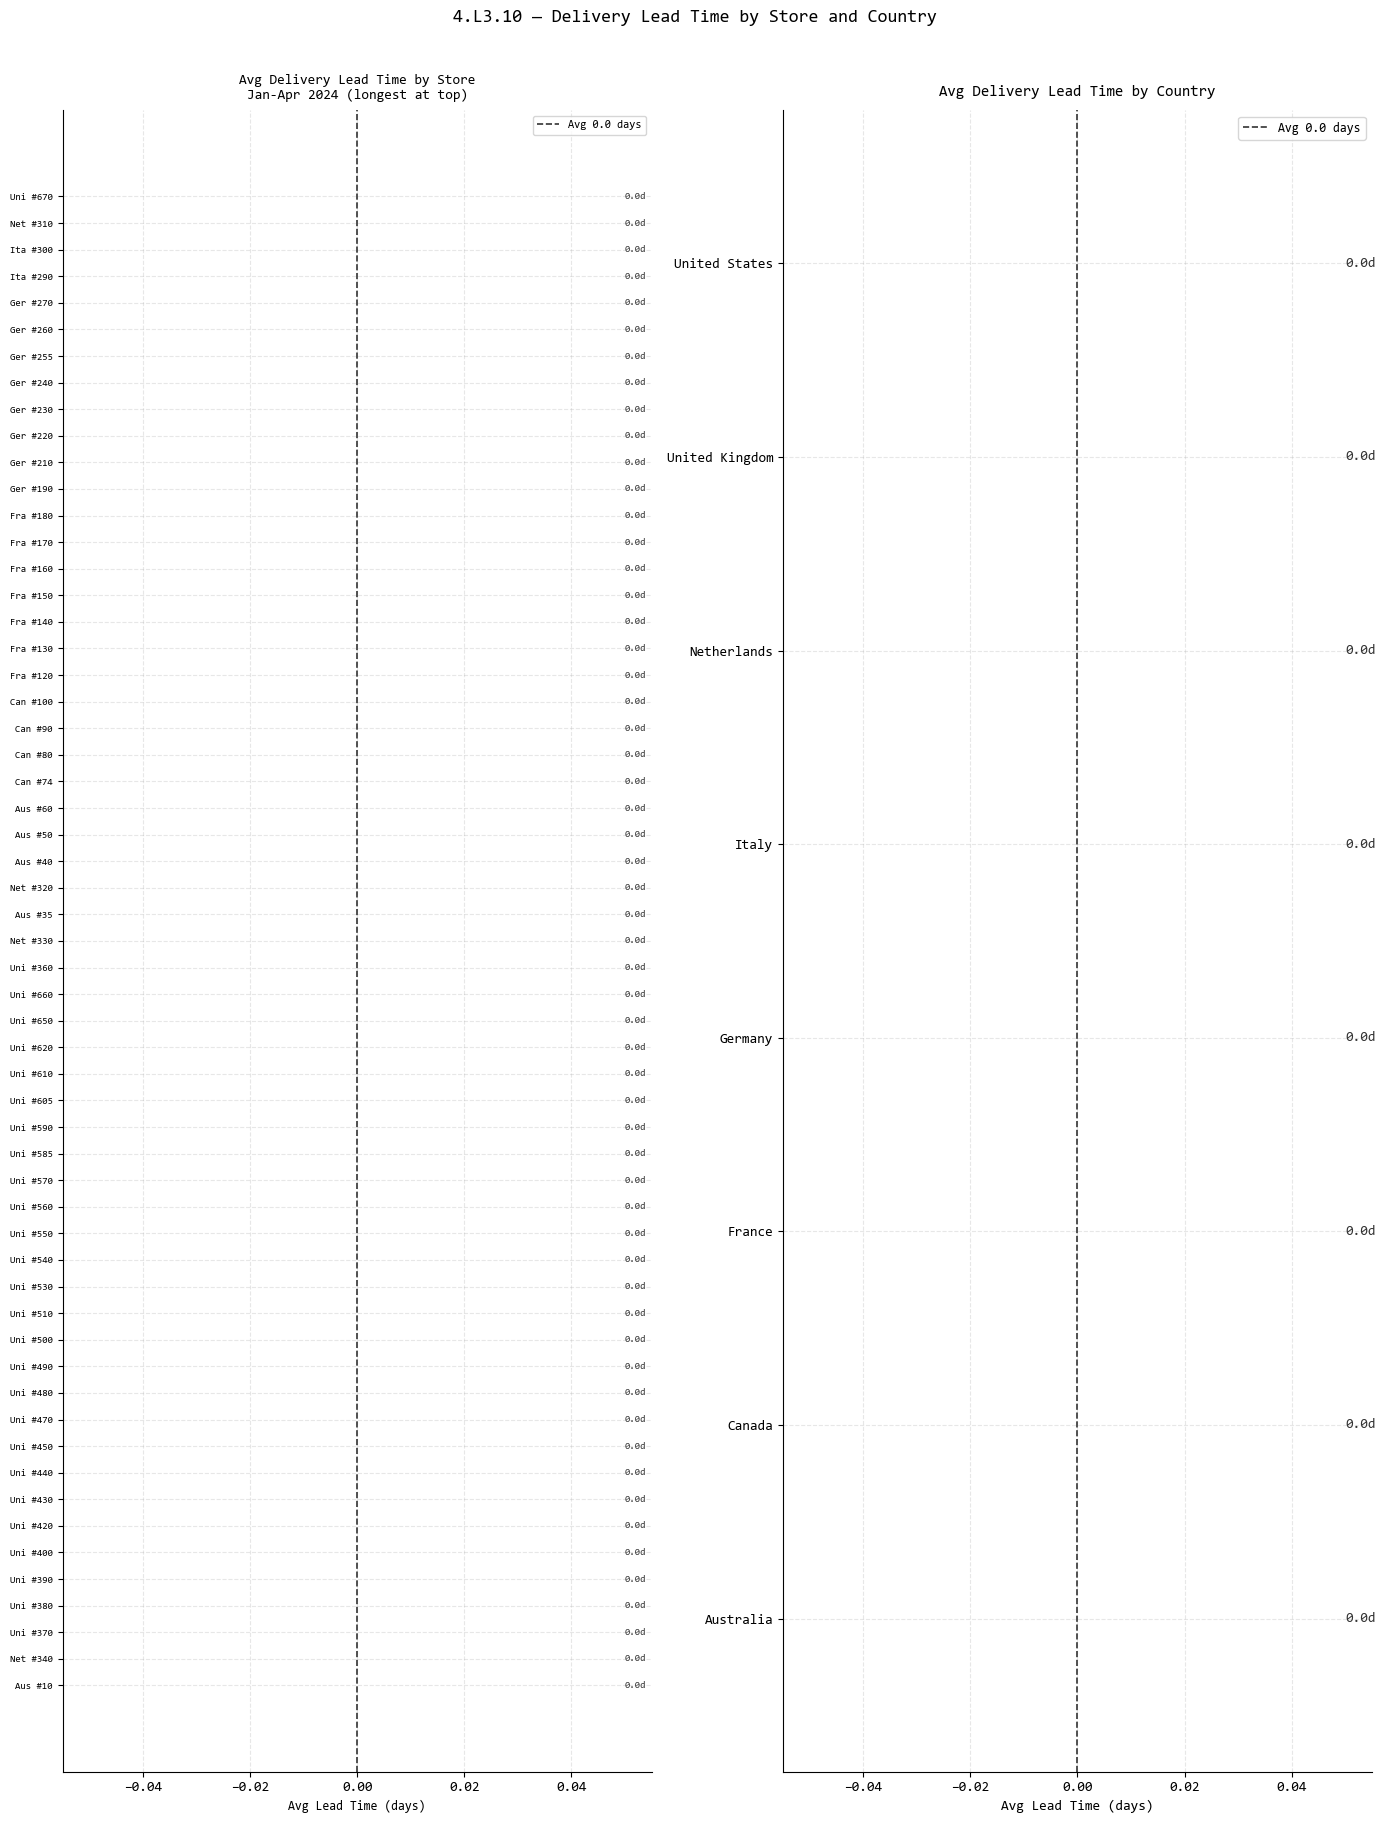

Network avg lead time: 0.0 days
Fastest store: 0.0 days | Slowest: 0.0 days


In [ ]:
# 4.L3.10 - Average delivery lead time by store Jan-Apr 2024
df_lead = pd.read_sql("""
    SELECT
        st.StoreKey,
        st.CountryName,
        COUNT(*) AS OrderLines,
        AVG(CAST(DATEDIFF(DAY, s.OrderDate, s.DeliveryDate) AS FLOAT)) AS AvgLeadDays,
        MIN(DATEDIFF(DAY, s.OrderDate, s.DeliveryDate)) AS MinLeadDays,
        MAX(DATEDIFF(DAY, s.OrderDate, s.DeliveryDate)) AS MaxLeadDays
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND st.CountryName != 'Online'
      AND s.DeliveryDate IS NOT NULL
      AND s.DeliveryDate >= s.OrderDate
    GROUP BY st.StoreKey, st.CountryName
    HAVING COUNT(*) >= 3
""", cnxn)

df_lead['Label'] = df_lead['CountryName'].str[:3] + ' #' + df_lead['StoreKey'].astype(str)
df_lead = df_lead.sort_values('AvgLeadDays', ascending=False).reset_index(drop=True)
network_avg_lead = df_lead['AvgLeadDays'].mean()

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 18))

# Ranked by lead time
ax = axes[0]
vals = df_lead['AvgLeadDays'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cm.RdYlGn_r(norm(v)) for v in vals]
bars = ax.barh(df_lead['Label'], vals, color=colors)
ax.axvline(network_avg_lead, color='#333333', linewidth=1.2, linestyle='--', label=f'Avg {network_avg_lead:.1f} days')
for bar, v in zip(bars, vals):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}d', ha='left', va='center', fontsize=7, color='#333333', fontfamily='Consolas')
ax.set_title('Avg Delivery Lead Time by Store\nJan-Apr 2024 (longest at top)', fontsize=10, fontfamily='Consolas', pad=8)
ax.set_xlabel('Avg Lead Time (days)', fontsize=9)
ax.tick_params(axis='y', labelsize=7)
ax.legend(fontsize=8)

# Country average
ax2 = axes[1]
country_lead = df_lead.groupby('CountryName')['AvgLeadDays'].mean().sort_values(ascending=False).reset_index()
vals2 = country_lead['AvgLeadDays'].values
norm2 = mcolors.Normalize(vmin=vals2.min(), vmax=vals2.max())
colors2 = [cm.RdYlGn_r(norm2(v)) for v in vals2]
bars2 = ax2.barh(country_lead['CountryName'], vals2, color=colors2)
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}d', ha='left', va='center', fontsize=10, color='#333333', fontfamily='Consolas')
ax2.axvline(network_avg_lead, color='#333333', linewidth=1.2, linestyle='--', label=f'Avg {network_avg_lead:.1f} days')
ax2.set_title('Avg Delivery Lead Time by Country', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('Avg Lead Time (days)', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('4.L3.10 — Delivery Lead Time by Store and Country', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
print(f"Network avg lead time: {network_avg_lead:.1f} days")
print(f"Fastest store: {df_lead['AvgLeadDays'].min():.1f} days | Slowest: {df_lead['AvgLeadDays'].max():.1f} days")

### Key Insight — 4.L3.10
**Delivery lead time analysis is not actionable from this dataset: OrderDate equals DeliveryDate for all physical store transactions (0-day lead time across all 57 stores), indicating that physical store sales are recorded as same-day point-of-sale transactions with no delivery gap.**
This means the DeliveryDate field represents the date goods were handed to the customer in-store (immediate fulfilment), not a shipment-to-home delivery. No differentiation in fulfilment speed exists across stores because all physical store purchases are collect-in-store.
For true delivery lead time analysis, online orders should be examined separately — the online channel would record meaningful shipping times between OrderDate and DeliveryDate that could highlight fulfilment performance differences by destination country.

> **Analysis Limitation:** This question is unanswerable for physical stores as framed — the data does not capture home delivery for store-originated orders. Recommend re-scoping to online channel delivery lead time for a meaningful analysis.